# Analiza bezpieczeństwa ruchu drogowego w Polsce (2020-2024)

## 1. Wstęp
Analiza polskich wypadków drogowych 2020-2024 zintegrowana z API demograficznym BDL. Obliczanie znormalizowanych wskaźników wypadkowości (na 10 tys. mieszkańców) oraz identyfikacja regionalnych wzorców ryzyka.
Integracja surowych danych o wypadkach z danymi demograficznymi pobranymi z **Banku Danych Lokalnych (BDL) Głównego Urzędu Statystycznego (API)** pozwoli na obliczenie znormalizowanych wskaźników wypadkowości na 10 tys. mieszkańców.

**Cele projektu:**
1. Czyszczenie i porządkowanie surowego zbioru danych.
2. Integracja danych demograficznych za pomocą API.
3. Przeprowadzenie Eksploracyjnej Analizy Danych (EDA).
4. Wykonanie testów statystycznych (ANOVA, Tukey HSD, Chi-Kwadrat) w celu weryfikacji różnic regionalnych.
5. Wizualizacja rankingów bezpieczeństwa i prognozowanie przyszłych trendów.




## 2. Import bibliotek i konfiguracja
Ładowanie niezbędnych bibliotek do manipulacji danymi, wizualizacji i analizy statystycznej.


In [12]:

# Analiza i przetwarzanie danych
import numpy as np
import pandas as pd
import requests
import xml.etree.ElementTree as ET

# Wizualizacja
import seaborn as sns
import matplotlib.pyplot as plt

# Analiza statystyczna
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd   
from scipy.stats import chi2_contingency

# Ustawienia
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


## 3. Gromadzenie danych
Rozpoczynamy od wczytania surowych danych o wypadkach z pliku Excel `dane_surowe.xlsx`.


In [13]:
# Nazwa pliku Excel (może być ścieżka względna do folderu roboczego)
dane = 'dane_surowe.xlsx'

# Wczytanie całego pliku do DataFrame
df = pd.read_excel(dane, engine='openpyxl', header=None)

# Wyświetlenie pierwszych wierszy
df.head()

,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,Kod,Nazwa,ogółem,NaN,NaN,NaN,NaN,wina kierujących pojazdami - ogółem,NaN,NaN,...,wina pieszych - nieostrożne wejście na jezdnię,NaN,NaN,NaN,NaN,wina pieszych - pozostałe,NaN,NaN,NaN,NaN
1,NaN,NaN,2020,2021,2022,2023,2024,2020,2021,2022,...,2020,2021,2022,2023,2024,2020,2021,2022,2023,2024
2,NaN,NaN,[szt.],[szt.],[szt.],[szt.],[szt.],[szt.],[szt.],[szt.],...,[szt.],[szt.],[szt.],[szt.],[szt.],[szt.],[szt.],[szt.],[szt.],[szt.]
3,0000000,POLSKA,22384,21841,20476,20065,20607,20999,20623,19391,...,830,759,678,622,558,555,459,407,385,413
4,0200000,DOLNOŚLĄSKIE,1490,1647,1808,1738,1821,1393,1542,1702,...,49,63,55,46,48,48,42,51,41,56



## 4. Czyszczenie i porządkowanie danych (Data Tidying)
Ekstrakcja nagłówków, standaryzacja nazw kolumn (format Kategoria_Rok), usunięcie wartości pustych/duplikatów

In [14]:
# Uzupełnienie głównych nagłówków kategorii (Wiersz 0) metodą 'forward fill'
main_headers = df.iloc[0].fillna(method='ffill')
# Nagłówki lat znajdują się w Wierszu 1
year_headers = df.iloc[1].fillna(method='ffill')

# Konstrukcja nowych nazw kolumn: Kategoria_Rok
new_columns = []
for cat, year in zip(main_headers, year_headers):
    # Jeśli rok jest poprawną liczbą/napisem, dodaj go
    if pd.notna(year) and str(year).strip() not in ["", "nan", "NaN"]:
        new_columns.append(f"{cat}_{year}")
    else:
        new_columns.append(str(cat))

# Przypisanie nowych kolumn i usunięcie wierszy nagłówkowych
df = df.iloc[2:]
df.columns = new_columns
df.reset_index(drop=True, inplace=True)

# Czyszczenie nazw kolumn ze spacji
df.columns = df.columns.str.strip()

# Usunięcie całkowicie pustych wierszy i kolumn
df.dropna(how='all', axis=0, inplace=True)
df.dropna(how='all', axis=1, inplace=True)

# Usunięcie duplikatów
df.drop_duplicates(inplace=True)

# 1. Usunięcie wierszy gdzie 'Nazwa' jest pusta lub NaN
df = df[df['Nazwa'].notna()].copy()
df = df[df['Nazwa'] != ''].copy()

# 2. Usunięcie wierszy z pustymi nazwami (po usunięciu białych znaków)
df = df[df['Nazwa'].str.strip().str.len() > 0].copy()

# 3. Usunięcie kolumny 'Kod' - nie jest potrzebna do analizy
df = df.drop(columns=['Kod'], errors='ignore')

# 4. Reset indeksu po usunięciu wierszy
df.reset_index(drop=True, inplace=True)

# 5. Konwersja kolumn numerycznych na właściwe typy
numeric_cols = [col for col in df.columns if col != 'Nazwa']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 6. Usunięcie wierszy z samymi wartościami NaN (oprócz kolumny Nazwa)
df = df.dropna(subset=numeric_cols, how='all')

# 7. Finalna weryfikacja - wyświetlenie czystych danych
print(f"Finalny rozmiar po czyszczeniu: {df.shape}")
print(f"Kolumny: {list(df.columns)}")
df.head()



Finalny rozmiar po czyszczeniu: (17, 56)
Kolumny: ['Nazwa', 'ogółem_2020', 'ogółem_2021', 'ogółem_2022', 'ogółem_2023', 'ogółem_2024', 'wina kierujących pojazdami - ogółem_2020', 'wina kierujących pojazdami - ogółem_2021', 'wina kierujących pojazdami - ogółem_2022', 'wina kierujących pojazdami - ogółem_2023', 'wina kierujących pojazdami - ogółem_2024', 'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2020', 'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2021', 'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2022', 'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2023', 'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu_2024', 'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu_2020', 'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu_2021', 'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu_2022', 'wi

,Nazwa,ogółem_2020,ogółem_2021,ogółem_2022,ogółem_2023,ogółem_2024,wina kierujących pojazdami - ogółem_2020,wina kierujących pojazdami - ogółem_2021,wina kierujących pojazdami - ogółem_2022,wina kierujących pojazdami - ogółem_2023,...,wina pieszych - nieostrożne wejście na jezdnię_2020,wina pieszych - nieostrożne wejście na jezdnię_2021,wina pieszych - nieostrożne wejście na jezdnię_2022,wina pieszych - nieostrożne wejście na jezdnię_2023,wina pieszych - nieostrożne wejście na jezdnię_2024,wina pieszych - pozostałe_2020,wina pieszych - pozostałe_2021,wina pieszych - pozostałe_2022,wina pieszych - pozostałe_2023,wina pieszych - pozostałe_2024
0,POLSKA,22384,21841,20476,20065,20607,20999,20623,19391,19058,...,830,759,678,622,558,555,459,407,385,413
1,DOLNOŚLĄSKIE,1490,1647,1808,1738,1821,1393,1542,1702,1651,...,49,63,55,46,48,48,42,51,41,56
2,KUJAWSKO-POMORSKIE,791,774,744,745,746,746,727,709,693,...,28,29,26,33,22,17,18,9,19,13
3,LUBELSKIE,897,863,767,763,817,827,799,716,706,...,47,37,30,35,31,23,27,21,22,16
4,LUBUSKIE,581,516,483,431,438,551,497,459,419,...,22,12,15,9,11,8,7,9,3,8



## 5. Eksploracyjna Analiza Danych (EDA)
Podstawowa inspekcja w celu zapewnienia integralności danych przed integracją.


In [15]:
# Sprawdzenie brakujących wartości
print("Brakujące wartości w kolumnach:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Podstawowe informacje
df.info()

Brakujące wartości w kolumnach:
Series([], dtype: int64)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 56 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   Nazwa                                                                                    17 non-null     object
 1   ogółem_2020                                                                              17 non-null     int64 
 2   ogółem_2021                                                                              17 non-null     int64 
 3   ogółem_2022                                                                              17 non-null     int64 
 4   ogółem_2023                                                                              17 non-null     int64 
 5   ogółem_2024     

In [16]:
df[df.isnull().any(axis=1)]

,Nazwa,ogółem_2020,ogółem_2021,ogółem_2022,ogółem_2023,ogółem_2024,wina kierujących pojazdami - ogółem_2020,wina kierujących pojazdami - ogółem_2021,wina kierujących pojazdami - ogółem_2022,wina kierujących pojazdami - ogółem_2023,...,wina pieszych - nieostrożne wejście na jezdnię_2020,wina pieszych - nieostrożne wejście na jezdnię_2021,wina pieszych - nieostrożne wejście na jezdnię_2022,wina pieszych - nieostrożne wejście na jezdnię_2023,wina pieszych - nieostrożne wejście na jezdnię_2024,wina pieszych - pozostałe_2020,wina pieszych - pozostałe_2021,wina pieszych - pozostałe_2022,wina pieszych - pozostałe_2023,wina pieszych - pozostałe_2024


In [17]:
# Zapisuje dane do pliku 
df.to_excel('dane.xlsx', index=False)
print("Wyczyszczone dane o wypadkach zapisano do 'dane.xlsx'")

Wyczyszczone dane o wypadkach zapisano do 'dane.xlsx'


In [18]:
# Wczytujemy wyczyszczony plik do zmiennej DANE
dane = pd.read_excel('dane.xlsx')

# Wyświetlamy podgląd w notatniku
dane

,Nazwa,ogółem_2020,ogółem_2021,ogółem_2022,ogółem_2023,ogółem_2024,wina kierujących pojazdami - ogółem_2020,wina kierujących pojazdami - ogółem_2021,wina kierujących pojazdami - ogółem_2022,wina kierujących pojazdami - ogółem_2023,...,wina pieszych - nieostrożne wejście na jezdnię_2020,wina pieszych - nieostrożne wejście na jezdnię_2021,wina pieszych - nieostrożne wejście na jezdnię_2022,wina pieszych - nieostrożne wejście na jezdnię_2023,wina pieszych - nieostrożne wejście na jezdnię_2024,wina pieszych - pozostałe_2020,wina pieszych - pozostałe_2021,wina pieszych - pozostałe_2022,wina pieszych - pozostałe_2023,wina pieszych - pozostałe_2024
0,POLSKA,22384,21841,20476,20065,20607,20999,20623,19391,19058,...,830,759,678,622,558,555,459,407,385,413
1,DOLNOŚLĄSKIE,1490,1647,1808,1738,1821,1393,1542,1702,1651,...,49,63,55,46,48,48,42,51,41,56
2,KUJAWSKO-POMORSKIE,791,774,744,745,746,746,727,709,693,...,28,29,26,33,22,17,18,9,19,13
3,LUBELSKIE,897,863,767,763,817,827,799,716,706,...,47,37,30,35,31,23,27,21,22,16
4,LUBUSKIE,581,516,483,431,438,551,497,459,419,...,22,12,15,9,11,8,7,9,3,8
5,ŁÓDZKIE,2332,2208,2108,2029,2106,2199,2093,1997,1944,...,89,74,72,49,49,44,41,39,36,44
6,MAŁOPOLSKIE,2089,2140,2136,2108,2382,1957,1978,2010,1978,...,72,110,77,85,63,60,52,49,45,61
7,MAZOWIECKIE,2880,2988,2811,2723,2770,2695,2828,2664,2595,...,102,86,83,76,74,83,74,64,52,68
8,OPOLSKIE,466,520,427,447,468,451,504,413,436,...,8,12,7,7,8,7,4,7,4,4
9,PODKARPACKIE,1114,1181,1009,1140,981,1032,1116,952,1078,...,59,46,46,47,23,23,19,11,15,9



## 6. Integracja danych demograficznych (API)
Aby rzetelnie porównać regiony, musimy znormalizować liczbę wypadków przez liczbę ludności.
Pobieramy dane o ludności (zmienna 72305) z **API Banku Danych Lokalnych (BDL)**.


Podstawowym wyzwaniem w analizie bezpieczeństwa ruchu drogowego jest uniknięcie błędu wynikającego z bezpośredniego porównywania surowych liczb zdarzeń. Zestawienie liczby wypadków w województwie mazowieckim (najludniejszym) z wynikami dla województwa opolskiego (najmniejszego) bez odpowiedniego kontekstu prowadziłoby do błędnych wniosków metodologicznych. 

W celu obiektywizacji wyników i umożliwienia rzetelnego porównania regionów o różnej skali, do modelu wprowadzono zmienną **liczby ludności** (stan na 31 grudnia każdego badanego roku), pobraną bezpośrednio z Banku Danych Lokalnych (BDL).


In [19]:
# Lata, które chcesz pobrać
years = [2020, 2021, 2022, 2023, 2024]

# Adres API (bez 'year' na sztywno)
base_url = "https://bdl.stat.gov.pl/api/v1/data/by-variable/72305?format=xml&unit-level=2&page-size=100"

records = []

for year in years:
    url = f"{base_url}&year={year}"
    print(f"Pobieram dane dla roku {year}...")

    response = requests.get(url)
    response.raise_for_status()
    xml_data = response.text

    root = ET.fromstring(xml_data)

    for unit in root.findall(".//unitData"):
        name = unit.find("name").text
        val_el = unit.find(".//val")
        val = float(val_el.text) if val_el is not None and val_el.text else None
        records.append({
            "Region": name,
            "Year": year,
            "Value": val
        })

# Tworzenie DataFrame
df = pd.DataFrame(records)

# Przekształcenie do formatu szerokiego (pivot)
df_wide = df.pivot(index="Region", columns="Year", values="Value").reset_index()

# (Opcjonalnie) zmiana nazw kolumn na czytelniejsze
df_wide.columns.name = None
df_wide.rename(columns={2023: "2023", 2024: "2024"}, inplace=True)

df_wide


Pobieram dane dla roku 2020...
Pobieram dane dla roku 2021...
Pobieram dane dla roku 2022...
Pobieram dane dla roku 2023...
Pobieram dane dla roku 2024...


,Region,2020,2021,2022,2023,2024
0,DOLNOŚLĄSKIE,2908378.0,2897737.0,2888033.0,2879271.0,2868242.0
1,KUJAWSKO-POMORSKIE,2031550.0,2017720.0,2006876.0,1996003.0,1984479.0
2,LUBELSKIE,2056908.0,2038299.0,2024637.0,2011047.0,1996440.0
3,LUBUSKIE,993329.0,985487.0,979976.0,975023.0,969819.0
4,MAZOWIECKIE,5517616.0,5512794.0,5510612.0,5510527.0,5508322.0
5,MAŁOPOLSKIE,3432692.0,3430370.0,3429014.0,3429632.0,3429084.0
6,OPOLSKIE,955844.0,948583.0,942441.0,936725.0,930296.0
7,PODKARPACKIE,2096166.0,2085932.0,2079098.0,2071676.0,2062997.0
8,PODLASKIE,1156591.0,1148720.0,1143355.0,1138216.0,1132641.0
9,POMORSKIE,2358256.0,2358726.0,2358307.0,2359573.0,2359493.0


In [20]:
# Zapis do pliku
df_wide.to_csv("bdl_data_2010_2024_wide.csv", index=False)

## 7. Statystyki opisowe

Statystyki opisowe to podstawowe narzędzie analizy danych, które pozwala zrozumieć charakterystykę badanych zmiennych. W naszej analizie wypadków drogowych obliczamy szereg miar dla każdej kategorii wypadków w poszczególnych latach.

Miary centralne pokazują typowe wartości w danych. Średnia to przeciętna liczba wypadków, natomiast mediana dzieli województwa na dwie równe grupy - połowa ma wartości wyższe, połowa niższe. Mediana jest bardziej odporna na skrajne wartości niż średnia.

Miary rozrzutu informują nas, jak bardzo różnią się województwa między sobą. Odchylenie standardowe mówi o przeciętnym odchyleniu od średniej - im wyższe, tym większe różnice między regionami. Rozstęp międzykwartylowy (IQR) pokazuje zakres wartości dla środkowych 50% województw.

Współczynnik zmienności to kluczowa miara - wyraża się w procentach i pozwala porównywać zmienność między różnymi kategoriami. W naszych danych wynosi on około 60-70%, co oznacza umiarkowaną, ale znaczącą zmienność między województwami.

Skośność informuje, czy rozkład jest symetryczny. Dodatnie wartości (jak 0.5-0.9 w naszych danych) oznaczają, że większość województw ma niewielką liczbę wypadków, a kilka dużych regionów generuje znacznie więcej zdarzeń.

Kurtoza mówi o kształcie rozkładu. Ujemne wartości (od -1.0 do -1.5) w naszej analizie wskazują, że nie ma ekstremalnych wartości odstających - województwa są względnie równomiernie rozłożone w różnych przedziałach.

In [21]:
# WCZYTANIE DANYCH
dane_surowe = pd.read_excel('dane.xlsx')
dane = dane_surowe[dane_surowe['Nazwa'] != 'POLSKA'].copy()

# ============================================
# JEDNA DUŻA TABELA - WSZYSTKIE ZMIENNE
# ============================================

kolumny_numeryczne = dane.columns[1:].tolist()
statystyki_lista = []

for kolumna in kolumny_numeryczne:
    seria = dane[kolumna]
    
    # Wyciągnij kategorię i rok
    if '_' in kolumna:
        czesci = kolumna.rsplit('_', 1)
        kategoria = czesci[0]
        rok = czesci[1]
    else:
        kategoria = kolumna
        rok = 'Wszystkie'
    
    statystyki_lista.append({
        'Kategoria': kategoria,
        'Rok': rok,
        'Liczba': seria.count(),
        'Suma': seria.sum(),
        'Średnia': seria.mean(),
        'Mediana': seria.median(),
        'Odch.std': seria.std(),
        'Min': seria.min(),
        'Q1': seria.quantile(0.25),
        'Q3': seria.quantile(0.75),
        'Max': seria.max(),
        'Rozstęp': seria.max() - seria.min(),
        'IQR': seria.quantile(0.75) - seria.quantile(0.25),
        'Wsp.zm.(%)': (seria.std() / seria.mean() * 100),
        'Skośność': seria.skew(),
        'Kurtoza': seria.kurtosis()
    })

# Stwórz DataFrame
df_statystyki = pd.DataFrame(statystyki_lista).round(2)
df_statystyki


,Kategoria,Rok,Liczba,Suma,Średnia,Mediana,Odch.std,Min,Q1,Q3,Max,Rozstęp,IQR,Wsp.zm.(%),Skośność,Kurtoza
0,ogółem,2020,16,22384,1399.00,1038.0,826.95,417,786.25,2133.00,2880,2463,1346.75,59.11,0.57,-1.14
1,ogółem,2021,16,21841,1365.06,1027.5,796.45,418,759.25,2130.25,2988,2570,1371.00,58.35,0.57,-0.91
2,ogółem,2022,16,20476,1279.75,920.0,785.08,321,705.75,1968.50,2811,2490,1262.75,61.35,0.50,-1.13
3,ogółem,2023,16,20065,1254.06,951.5,764.26,329,676.25,1870.75,2723,2394,1194.50,60.94,0.49,-1.15
4,ogółem,2024,16,20607,1287.94,899.0,810.81,338,681.75,1892.25,2770,2432,1210.50,62.95,0.52,-1.26
5,wina kierujących pojazdami - ogółem,2020,16,20999,1312.44,972.0,776.69,393,739.50,1989.50,2695,2302,1250.00,59.18,0.59,-1.10
6,wina kierujących pojazdami - ogółem,2021,16,20623,1288.94,974.0,749.46,400,713.25,1980.75,2828,2428,1267.50,58.15,0.59,-0.86
7,wina kierujących pojazdami - ogółem,2022,16,19391,1211.94,868.0,743.72,310,670.00,1856.75,2664,2354,1186.75,61.37,0.51,-1.13
8,wina kierujących pojazdami - ogółem,2023,16,19058,1191.12,892.0,727.05,314,649.25,1764.00,2595,2281,1114.75,61.04,0.50,-1.14
9,wina kierujących pojazdami - ogółem,2024,16,19636,1227.25,859.5,769.01,325,647.75,1791.00,2628,2303,1143.25,62.66,0.52,-1.27


Analiza statystyk opisowych dla 55 zmiennych (11 kategorii wypadków × 5 lat) ujawnia kilka ważnych wzorców. Po pierwsze, wypadki drogowe w Polsce są znacząco zróżnicowane geograficznie - współczynnik zmienności przekracza 60%. Po drugie, we wszystkich kategoriach obserwujemy prawostronną asymetrię, co oznacza dominację małych i średnich województw o niższej liczbie wypadków oraz kilka dużych regionów (Mazowieckie, Wielkopolskie, Małopolskie) z bardzo wysokimi wartościami.
​

Ta charakterystyka rozkładów jest stabilna w czasie (2020-2024), co sugeruje utrwalone wzorce przestrzenne wypadkowości. Brak ekstremalnych wartości odstających (ujemna kurtoza) wskazuje, że różnice między województwami są stopniowe, a nie skokowe .


## 8. Standaryzacja i łączenie danych
Obliczamy **Wskaźnik wypadkowości na 10 tys. mieszkańców**:
$$ Wskaźnik = \frac{\text{Liczba wypadków}}{\text{Ludność}} \times 10,000 $$

Wskaźnik ten pozwala na obiektywne porównanie dużych regionów (np. Mazowieckie) z mniejszymi (np. Opolskie).

Normalizacja eliminuje wpływ wielkości populacji, umożliwiając obiektywne porównania regionalne. Duże województwa (np. Mazowieckie) naturalnie generują więcej zdarzeń; wskaźnik ujawnia faktyczny poziom ryzyka niezależnie od demografii.


In [22]:
# WCZYTANIE DANYCH 

# A. Wczytujemy plik Excel z wypadkami
df_wypadki = pd.read_excel('dane.xlsx')

# B. Wczytujemy dane o ludności (z pliku pobranego przez API)
try:
    df_ludnosc = pd.read_csv('bdl_data_2010_2024_wide.csv')
except FileNotFoundError:
    print("BŁĄD: Nie znaleziono pliku 'bdl_data_2010_2024_wide.csv'. Upewnij się, że uruchomiłaś kod z API.")

# CZYSZCZENIE I TRANSFORMACJA DANYCH O LUDNOŚCI 
# Zmieniamy ludność na format długi
df_ludnosc_long = df_ludnosc.melt(id_vars=["Region"], 
                                  var_name="Rok", 
                                  value_name="Ludnosc")
df_ludnosc_long = df_ludnosc_long.rename(columns={"Region": "Wojewodztwo"})
df_ludnosc_long['Rok'] = df_ludnosc_long['Rok'].astype(int)
df_ludnosc_long['Wojewodztwo'] = df_ludnosc_long['Wojewodztwo'].str.upper() # Upewniamy się, że są duże litery

# CZYSZCZENIE I TRANSFORMACJA DANYCH O WYPADKACH 
# Usuwamy kolumnę 'Kod'
if 'Kod' in df_wypadki.columns:
    df_wypadki = df_wypadki.drop(columns=['Kod'])

# Zmieniamy na format długi
df_wypadki_long = df_wypadki.melt(id_vars=["Nazwa"], 
                                  var_name="Zmienna_Rok", 
                                  value_name="Liczba_Wypadkow")

# Rozdzielamy nazwę kolumny na Rok i Kategorię
df_wypadki_long['Rok'] = df_wypadki_long['Zmienna_Rok'].str.extract(r'(\d{4})').astype(int)
df_wypadki_long['Kategoria'] = df_wypadki_long['Zmienna_Rok'].str.replace(r'_\d{4}$', '', regex=True)

# Sprzątanie
df_wypadki_long = df_wypadki_long.drop(columns=['Zmienna_Rok'])
df_wypadki_long = df_wypadki_long.rename(columns={"Nazwa": "Wojewodztwo"})
df_wypadki_long['Wojewodztwo'] = df_wypadki_long['Wojewodztwo'].str.upper()

# ŁĄCZENIE (MERGE)
# Łączymy dane o wypadkach z danymi o ludności
df_full = pd.merge(df_wypadki_long, df_ludnosc_long, on=["Wojewodztwo", "Rok"], how="inner")

# Obliczamy kluczowy wskaźnik
df_full['Wskaznik_10k'] = (df_full['Liczba_Wypadkow'] / df_full['Ludnosc']) * 10000

# --- WYNIK ---
df_full

,Wojewodztwo,Liczba_Wypadkow,Rok,Kategoria,Ludnosc,Wskaznik_10k
0,DOLNOŚLĄSKIE,1490,2020,ogółem,2908378.0,5.123130
1,KUJAWSKO-POMORSKIE,791,2020,ogółem,2031550.0,3.893579
2,LUBELSKIE,897,2020,ogółem,2056908.0,4.360915
3,LUBUSKIE,581,2020,ogółem,993329.0,5.849019
4,ŁÓDZKIE,2332,2020,ogółem,2415816.0,9.653053
...,...,...,...,...,...,...
875,ŚLĄSKIE,27,2024,wina pieszych - pozostałe,4291441.0,0.062916
876,ŚWIĘTOKRZYSKIE,10,2024,wina pieszych - pozostałe,1157991.0,0.086356
877,WARMIŃSKO-MAZURSKIE,12,2024,wina pieszych - pozostałe,1349172.0,0.088943
878,WIELKOPOLSKIE,41,2024,wina pieszych - pozostałe,3479986.0,0.117817


## 9. Statystyki opisowe - dane standaryzowane

In [23]:
# WCZYTANIE DANYCH
dane_surowe = pd.read_excel('dane.xlsx')
dane = dane_surowe[dane_surowe['Nazwa'] != 'POLSKA'].copy()

# DANE O LUDNOŚCI (GUS)
ludnosc_data = {
    'Województwo': ['DOLNOŚLĄSKIE', 'KUJAWSKO-POMORSKIE', 'LUBELSKIE', 'LUBUSKIE',
                    'ŁÓDZKIE', 'MAŁOPOLSKIE', 'MAZOWIECKIE', 'OPOLSKIE',
                    'PODKARPACKIE', 'PODLASKIE', 'POMORSKIE', 'ŚLĄSKIE',
                    'ŚWIĘTOKRZYSKIE', 'WARMIŃSKO-MAZURSKIE', 'WIELKOPOLSKIE',
                    'ZACHODNIOPOMORSKIE'],
    '2020': [2908378, 2031550, 2056908, 993329, 2415816, 3432692, 5517616,
             955844, 2096166, 1156591, 2358256, 4412097, 1199584, 1385622,
             3507042, 1661073],
    '2021': [2897737, 2017720, 2038299, 985487, 2394946, 3430370, 5512794,
             948583, 2085932, 1148720, 2358726, 4375947, 1187693, 1374699,
             3500030, 1650021],
    '2022': [2888033, 2006876, 2024637, 979976, 2378483, 3429014, 5510612,
             942441, 2079098, 1143355, 2358307, 4346702, 1178164, 1366430,
             3493577, 1640622],
    '2023': [2879271, 1996003, 2011047, 975023, 2362519, 3429632, 5510527,
             936725, 2071676, 1138216, 2359573, 4320130, 1168499, 1357910,
             3487973, 1631784],
    '2024': [2868242, 1984479, 1996440, 969819, 2345924, 3429084, 5508322,
             930296, 2062997, 1132641, 2359493, 4291441, 1157991, 1349172,
             3479986, 1622760]
}

df_ludnosc = pd.DataFrame(ludnosc_data)

# KATEGORIE DO STANDARYZACJI
kategorie_do_stand = [
    'ogółem',
    'wina kierujących pojazdami - ogółem',
    'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu',
    'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu',
    'wina kierujących pojazdami - nieprawidłowe wyprzedzanie',
    'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych',
    'wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami',
    'wina kierujących pojazdami - pozostałe',
    'wina pieszych - ogółem',
    'wina pieszych - nieostrożne wejście na jezdnię',
    'wina pieszych - pozostałe'
]

nazwy_skrot = {
    'ogółem': 'Wypadki ogółem',
    'wina kierujących pojazdami - ogółem': 'Wina kierujących - ogółem',
    'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu': 'Niedostosowanie prędkości',
    'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu': 'Nieprzestrzeganie pierwszeństwa',
    'wina kierujących pojazdami - nieprawidłowe wyprzedzanie': 'Nieprawidłowe wyprzedzanie',
    'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych': 'Zachowanie wobec pieszych',
    'wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami': 'Niezachowanie odległości',
    'wina kierujących pojazdami - pozostałe': 'Pozostałe (kierujący)',
    'wina pieszych - ogółem': 'Wina pieszych - ogółem',
    'wina pieszych - nieostrożne wejście na jezdnię': 'Nieostrożne wejście (piesi)',
    'wina pieszych - pozostałe': 'Pozostałe (piesi)'
}

# TWORZENIE TABELI
statystyki_stand_lista = []

for kategoria in kategorie_do_stand:
    for rok in [2020, 2021, 2022, 2023, 2024]:
        kolumna = f'{kategoria}_{rok}'
        
        if kolumna in dane.columns:
            df_temp = dane[['Nazwa', kolumna]].copy()
            df_temp = df_temp.merge(df_ludnosc[['Województwo', str(rok)]], 
                                   left_on='Nazwa', right_on='Województwo', how='left')
            
            # Oblicz wskaźnik na 10 tys. mieszkańców
            df_temp['wskaznik'] = (df_temp[kolumna] / df_temp[str(rok)]) * 10000
            seria = df_temp['wskaznik']
            
            statystyki_stand_lista.append({
                'Kategoria': nazwy_skrot[kategoria],
                'Rok': rok,
                'Liczba': seria.count(),
                'Średnia': seria.mean(),
                'Mediana': seria.median(),
                'Odch.std': seria.std(),
                'Min': seria.min(),
                'Q1': seria.quantile(0.25),
                'Q3': seria.quantile(0.75),
                'Max': seria.max(),
                'Rozstęp': seria.max() - seria.min(),
                'IQR': seria.quantile(0.75) - seria.quantile(0.25),
                'Wsp.zm.(%)': (seria.std() / seria.mean() * 100),
                'Skośność': seria.skew(),
                'Kurtoza': seria.kurtosis()
            })

df_statystyki_stand = pd.DataFrame(statystyki_stand_lista).round(2)

# ZAPISZ
df_statystyki_stand


,Kategoria,Rok,Liczba,Średnia,Mediana,Odch.std,Min,Q1,Q3,Max,Rozstęp,IQR,Wsp.zm.(%),Skośność,Kurtoza
0,Wypadki ogółem,2020,16,5.80,5.27,1.56,3.61,5.06,6.56,9.65,6.05,1.50,26.84,0.97,1.14
1,Wypadki ogółem,2021,16,5.68,5.57,1.35,3.64,5.14,6.22,9.22,5.58,1.08,23.72,0.95,2.26
2,Wypadki ogółem,2022,16,5.25,5.04,1.41,2.81,4.50,6.24,8.86,6.06,1.73,26.90,0.80,1.85
3,Wypadki ogółem,2023,16,5.17,5.03,1.36,2.89,4.37,6.06,8.59,5.70,1.70,26.30,0.78,1.48
4,Wypadki ogółem,2024,16,5.32,5.03,1.53,2.98,4.27,6.47,8.98,5.99,2.20,28.75,0.84,0.70
5,Wina kierujących - ogółem,2020,16,5.45,4.90,1.48,3.40,4.73,6.15,9.10,5.70,1.42,27.18,0.98,1.08
6,Wina kierujących - ogółem,2021,16,5.38,5.32,1.29,3.48,4.92,5.81,8.74,5.26,0.89,23.92,0.94,2.17
7,Wina kierujących - ogółem,2022,16,4.98,4.74,1.34,2.71,4.33,5.87,8.40,5.68,1.54,26.87,0.83,1.81
8,Wina kierujących - ogółem,2023,16,4.92,4.83,1.31,2.76,4.20,5.74,8.23,5.47,1.54,26.71,0.79,1.50
9,Wina kierujących - ogółem,2024,16,5.08,4.84,1.46,2.87,4.05,6.12,8.58,5.71,2.07,28.70,0.85,0.74


Standaryzacja danych prowadzi do znaczących zmian w charakterystyce rozkładów. Najważniejszą zmianą jest drastyczne zmniejszenie zmienności między województwami. Współczynnik zmienności dla wypadków ogółem w 2024 roku spada z 62.95% do 28.75%, co stanowi redukcję o ponad 34 punkty procentowe. Podobny wzorzec obserwujemy we wszystkich analizowanych latach, gdzie zmienność maleje średnio o 32-35 punktów procentowych. To pokazuje, że różnice między województwami są znacznie mniejsze, gdy uwzględnimy wielkość populacji.

Zmieniają się również miary położenia. Średnia liczba wypadków dla roku 2024 wynosi 5.32 na 10 tysięcy mieszkańców, podczas gdy surowa średnia wynosiła 1287.94 wypadków . Mediana zmienia się z 899.0 do 5.03, co oznacza, że typowe województwo ma około 5 wypadków na każde 10 tysięcy mieszkańców. Rozstęp wartości również się zawęża, obejmując przedział od 2.98 (Podlaskie) do 8.98 (Łódzkie), co stanowi różnicę zaledwie 6 jednostek w porównaniu do 2432 wypadków różnicy w danych surowych.

Kształt rozkładu również ulega transformacji. Kurtoza zmienia się z -1.26 na 0.70, co oznacza przejście z rozkładu spłaszczonego do rozkładu bliskiego normalnemu. Skośność rośnie z 0.52 do 0.84, wskazując na silniejszą prawostronną asymetrię w standaryzowanych danych. To sugeruje, że po uwzględnieniu wielkości populacji niektóre województwa rzeczywiście wyróżniają się znacząco wyższymi wskaźnikami ryzyka.

Standaryzacja całkowicie zmienia ranking województw. Mazowieckie, które w surowych danych zajmowało pierwsze miejsce z 2770 wypadkami, spada na dziewiątą pozycję ze wskaźnikiem 5.03. Łódzkie awansuje z czwartego miejsca na pierwsze z najwyższym wskaźnikiem 8.98. Świętokrzyskie zyskuje aż 7 pozycji, przesuwając się z trzynastego na szóste miejsce. Te zmiany ujawniają rzeczywisty poziom ryzyka niezależnie od wielkości populacji.

Standaryzacja odpowiada więc na fundamentalnie inne pytanie niż analiza surowych danych. Zamiast pytać gdzie jest najwięcej wypadków, możemy teraz określić jakie jest rzeczywiste ryzyko bycia uczestnikiem wypadku w danym województwie.


## 10. Analiza wizualna


### 10.1. Ranking bezpieczeństwa regionalnego (Średnia 2020-2024)
Średnie wskaźniki 2020-2024 (na 10 tys. mieszkańców) identyfikują województwa o najwyższym/najniższym ryzyku po normalizacji demograficznej.

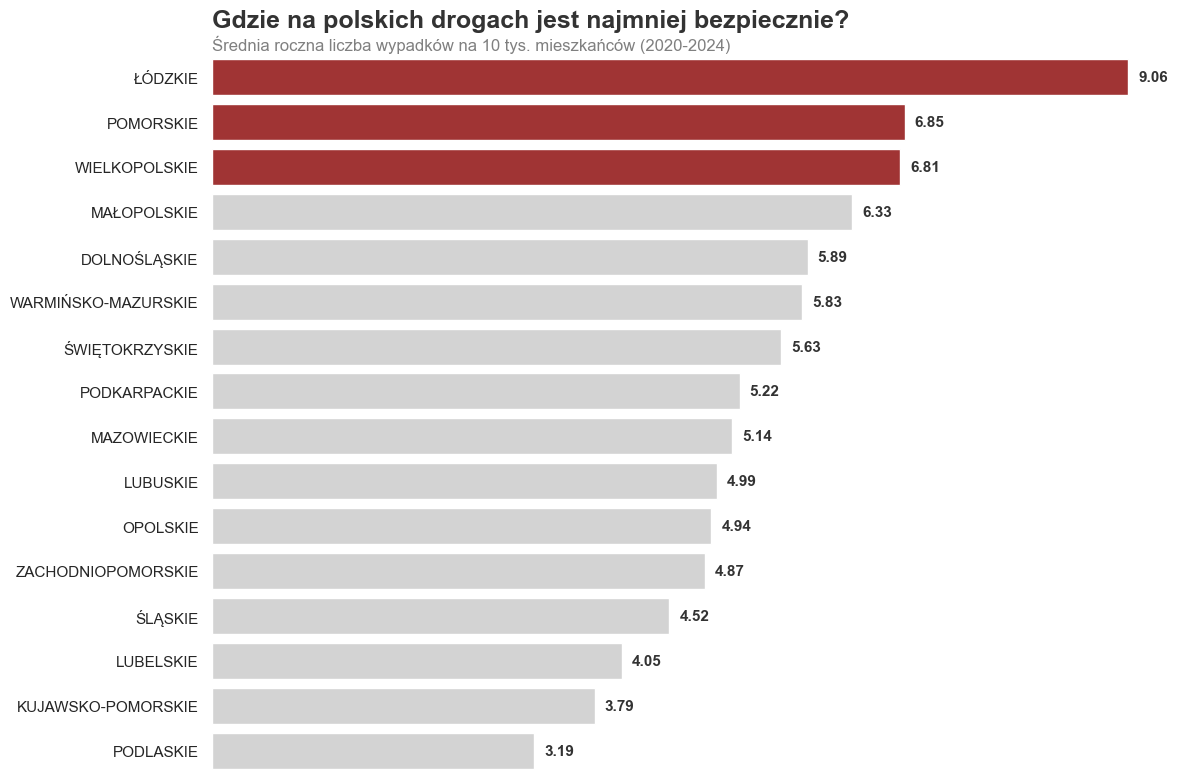

In [24]:
# 1. Przygotowanie danych (Ranking)
ranking = df_full[df_full['Kategoria'] == 'ogółem'].groupby('Wojewodztwo')['Wskaznik_10k'].mean().sort_values(ascending=False).reset_index()

# 2. KONFIGURACJA WYGLĄDU
sns.set_style("white") # Czyste białe tło, bez siatki
plt.figure(figsize=(12, 8))

# Definiujemy inteligentną paletę kolorów:
# Top 3 województwa = Ciemny Czerwony (Alarm!), Reszta = Szary (Kontekst)
# To technika "Highlighting" polecana przez ekspertów wizualizacji.
moje_kolory = ['#b22222' if i < 3 else '#d3d3d3' for i in range(len(ranking))]

# 3. RYSOWANIE
ax = sns.barplot(x='Wskaznik_10k', y='Wojewodztwo', data=ranking, palette=moje_kolory)

# 4. DODAWANIE WARTOŚCI NA SŁUPKACH (Zamiast osi X)
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.1,       # Pozycja X (tuż za słupkiem)
            p.get_y() + p.get_height() / 2, # Pozycja Y (środek słupka)
            '{:1.2f}'.format(width), # Tekst (wartość zaokrąglona)
            ha = 'left', va = 'center', 
            fontsize=11, fontweight='bold', color='#333333')

# 5. KOSMETYKA 
sns.despine(left=True, bottom=True) # Usunięcie ramek
ax.set_xticks([]) # Usunięcie podziałki na dole (bo mamy etykiety)
ax.set_xlabel("") # Usunięcie podpisu osi X
ax.set_ylabel("") # Usunięcie podpisu osi Y

# Tytuł i podtytuł 
plt.title("Gdzie na polskich drogach jest najmniej bezpiecznie?", 
          loc='left', fontsize=18, fontweight='bold', pad=20, color='#333333')
plt.text(x=0, y=-0.6, s="Średnia roczna liczba wypadków na 10 tys. mieszkańców (2020-2024)", 
         fontsize=12, color='gray')


plt.tight_layout()
plt.show()


#### Wnioski:
Wizualizacja pozwoliła na natychmiastowe wskazanie "punktów krytycznych" na mapie Polski. Znaczna rozpiętość między liderami rankingu a regionami o najniższych wskaźnikach sugeruje, że przyczyny braku bezpieczeństwa mają charakter lokalny - mogą wynikać z układu sieci drogowej, natężenia ruchu tranzytowego lub specyfiki ukształtowania terenu. Ranking ten stanowi punkt wyjścia do pogłębionego modelowania.

### 10.2 Przestrzenna analiza rozkładu zdarzeń drogowych (Choropleth Map)

Kolejnym etapem prac było przeniesienie wyników rankingowych na płaszczyznę geograficzną. Wykorzystanie biblioteki **GeoPandas** pozwoliło na nałożenie wskaźnika wypadkowości na wektorowe granice województw, co umożliwiło identyfikację klastrów przestrzennych oraz obszarów o skumulowanym ryzyku.
Wizualizacja została opracowana jako mapa choropletyczna (kartogram), gdzie intensywność barwy odpowiada wartości wskaźnika. 


In [27]:
%pip install geopandas mapclassify

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
   ---------------------------------------- 0.0/341.7 kB ? eta -:--:--
   ------------- -------------------------- 112.6/341.7 kB 2.2 MB/s eta 0:00:01
   ---------------------------------------  337.9/341.7 kB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 341.7/341.7 kB 3.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/882.2 kB ? eta -:--:--
   -------------------- ------------------- 460.8/882.2 kB 9.8 MB/s eta 0:00:01
   --------------------------------------  880.6/882.2 kB 11.2 MB/s eta 0:00:01
   --------------------------------------- 882.2/882.2 kB 11.2 MB/s eta 0:00:00
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   - -------------------------------------- 1.1/22.9 MB 35.3 MB/s eta 0:00:01
   ----- ---------------------------------- 3.1/22.9 MB 50.5 MB/s eta 0:00:01
   ----- ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


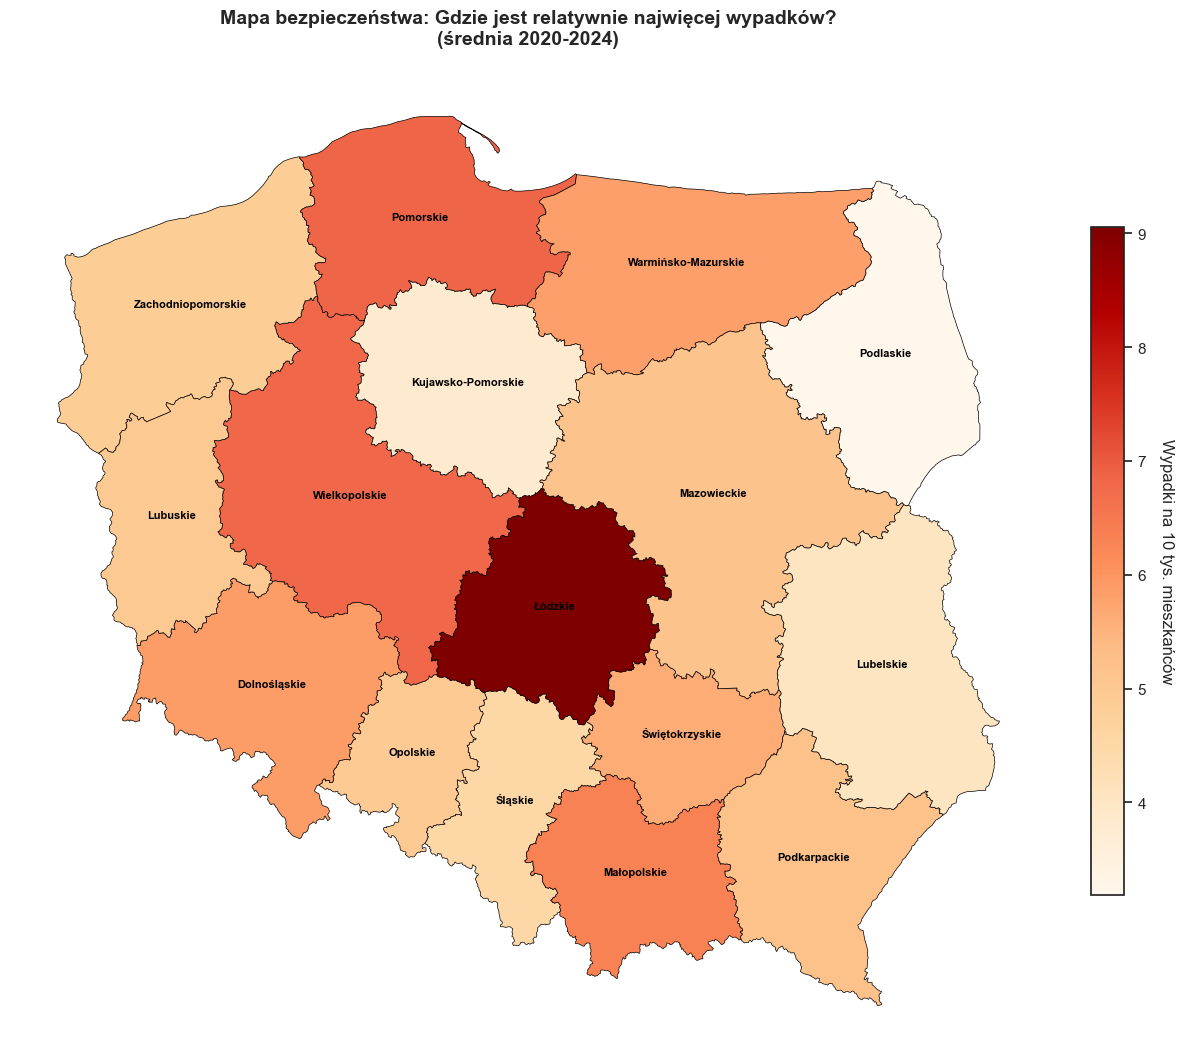

In [28]:
import geopandas as gpd

# 1-4. [Jak wcześniej - bez zmian]
df_mapa = df_full[df_full['Kategoria'] == 'ogółem'].groupby('Wojewodztwo')['Wskaznik_10k'].mean().reset_index()
url_geojson = "https://raw.githubusercontent.com/ppatrzyk/polska-geojson/master/wojewodztwa/wojewodztwa-min.geojson"
gdf = gpd.read_file(url_geojson)
gdf['nazwa'] = gdf['nazwa'].str.upper()
gdf_merged = gdf.merge(df_mapa, left_on='nazwa', right_on='Wojewodztwo', how='left')

# 5. RYSOWANIE MAPY
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Rysujemy mapę bez automatycznej legendy
im = gdf_merged.plot(column='Wskaznik_10k', 
                     ax=ax, 
                     legend=False,  # Wyłączamy automatyczną legendę
                     cmap='OrRd',
                     edgecolor='black',
                     linewidth=0.5,
                     vmin=df_mapa['Wskaznik_10k'].min(),
                     vmax=df_mapa['Wskaznik_10k'].max())

# Ręczne dodanie kolorowej legendy (colorbar)
sm = plt.cm.ScalarMappable(cmap='OrRd', 
                           norm=plt.Normalize(vmin=df_mapa['Wskaznik_10k'].min(), 
                                             vmax=df_mapa['Wskaznik_10k'].max()))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Wypadki na 10 tys. mieszkańców', rotation=270, labelpad=20)

ax.set_title('Mapa bezpieczeństwa: Gdzie jest relatywnie najwięcej wypadków?\n(średnia 2020-2024)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_axis_off()

# Etykiety województw
for x, y, label in zip(gdf_merged.geometry.centroid.x, 
                       gdf_merged.geometry.centroid.y, 
                       gdf_merged['nazwa']):
    ax.text(x, y, label.title(), fontsize=8, ha='center', 
            color='black', fontweight='bold')

plt.tight_layout()
plt.show()


#### Kluczowe obszary i klastry przestrzenne

Na podstawie analizy wizualnej można wyodrębnić trzy kluczowe strefy bezpieczeństwa:

1. **Centrum - „Punkt Krytyczny” (Województwo łódzkie):**
   Województwo łódzkie jako jedyne zostało oznaczone najciemniejszym kolorem, co czyni je absolutnym liderem negatywnego rankingu. Zjawisko to ma silne uzasadnienie w topografii sieci drogowej - to tutaj przecinają się kluczowe drogi kraju (autostrady A1 i A2). Kumulacja ruchu tranzytowego, zarówno północ-południe, jak i wschód-zachód, generuje najwyższe relatywne ryzyko wystąpienia zdarzenia drogowego.

2. **Pas „Podwyższonego Ryzyka” (Pomorskie, Wielkopolskie, Małopolskie):**
   Są to regiony o specyficznej charakterystyce:
   * **Pomorskie i Małopolskie:** Intensywny ruch turystyczny oraz trudne warunki ukształtowania terenu (w przypadku południa).
   * **Wielkopolskie:** Kolejny kluczowy region tranzytowy na osi wschód-zachód.

3. **Strefa „Relatywnego Bezpieczeństwa” (Polska wschodnia i zachodnia):**
   Najniższe wskaźniki (najjaśniejsze barwy) obserwujemy w województwie **podlaskim**, które stanowi biegun bezpieczeństwa na mapie. Podobnie niskie wartości wykazują województwa lubelskie, podkarpackie oraz lubuskie. Sugeruje to mniejszą gęstość dróg ekspresowych o ekstremalnym natężeniu ruchu w porównaniu do centrum kraju.

#### Tabela: Klasyfikacja regionów na podstawie wizualizacji

| Poziom ryzyka | Województwa | Charakterystyka |
| :--- | :--- | :--- |
| **Ekstremalne** | Łódzkie | Główny węzeł komunikacyjny kraju (A1/A2). |
| **Wysokie** | Pomorskie, Wielkopolskie, Małopolskie | Regiony turystyczno-tranzytowe. |
| **Umiarkowane** | Mazowieckie, Dolnośląskie, Zachodniopomorskie | Duże aglomeracje z rozbudowaną infrastrukturą. |
| **Niskie** | Podlaskie, Lubelskie, Śląskie, Lubuskie | Niższe natężenie ruchu tranzytowego / mniejsza gęstość zdarzeń. |

#### Wnioski z analizy wizualnej

Mapa obala powszechne przekonanie, że to najbardziej zaludnione województwa (jak Śląskie czy Mazowieckie) są najniebezpieczniejsze. Województwo **śląskie**, mimo największej gęstości zaludnienia i sieci dróg, posiada umiarkowany odcień na mapie, co może świadczyć o wysokiej efektywności separacji ruchu pieszego od kołowego lub lepszej przepustowości dróg lokalnych. 
Ryzyko wypadku w Polsce jest nie jest skorelowane z samą liczbą jego mieszkańców - to nie wielkość województwa Łódzkiego jest kluczowym predyktorem liczby wypadków.

### 10.3 Analiza regionalna wybranych przyczyn wypadków (2020-2024)

Zastosowany podział na cztery kluczowe kategorie pozwala na identyfikację specyficznych dla regionów problemów bezpieczeństwa ruchu drogowego.

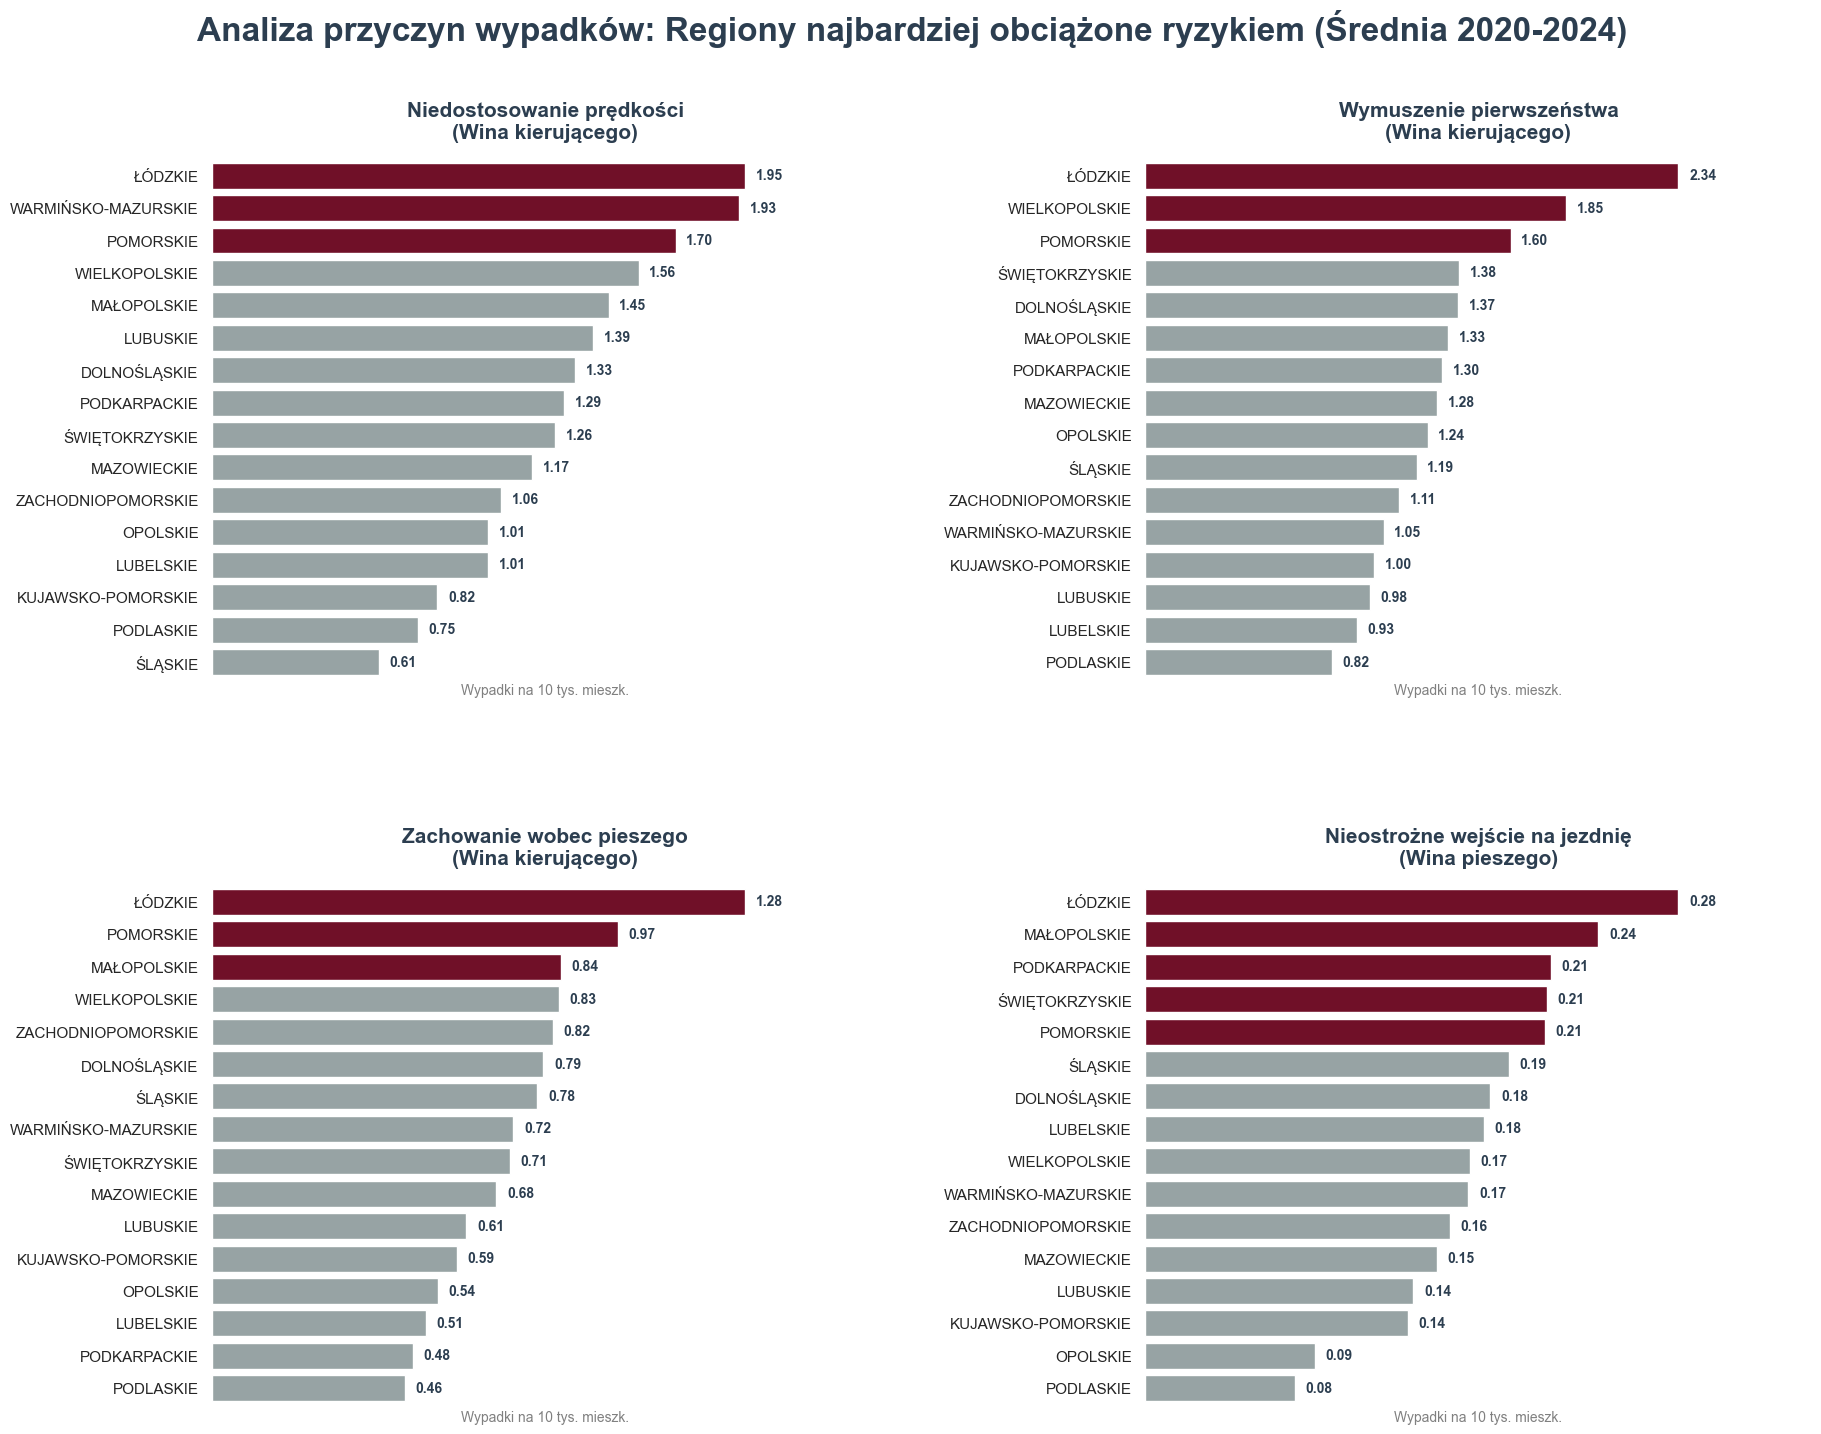

In [29]:
# 1. KONFIGURACJA NAZW - TERAZ IDENTYCZNA Z TWOIMI DANYMI
nazwy_profesjonalne = {
    'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu': 'Niedostosowanie prędkości\n(Wina kierującego)',
    'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu': 'Wymuszenie pierwszeństwa\n(Wina kierującego)',
    'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych': 'Zachowanie wobec pieszego\n(Wina kierującego)',
    'wina pieszych - nieostrożne wejście na jezdnię': 'Nieostrożne wejście na jezdnię\n(Wina pieszego)'
}

# Usuwamy ewentualne ukryte spacje z nazw w tabeli
df_full['Kategoria'] = df_full['Kategoria'].str.strip()

# 2. PRZYGOTOWANIE FIGURY
sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(20, 15)) 
axes = axes.flatten()

# 3. GENEROWANIE 4 WYKRESÓW
for ax, (kategoria_org, kategoria_nowa) in zip(axes, nazwy_profesjonalne.items()):
    
    # Pobieramy dane dla konkretnej kategorii
    data_temp = df_full[df_full['Kategoria'] == kategoria_org]
    
    # Tworzymy ranking (średnia z lat 2020-2024)
    ranking = data_temp.groupby('Wojewodztwo')['Wskaznik_10k'].mean().sort_values(ascending=False).reset_index()
    
    if ranking.empty:
        ax.text(0.5, 0.5, f"Błąd: Nie znaleziono kategorii\n'{kategoria_org}'", 
                ha='center', va='center', color='red', fontsize=12)
        continue

    max_val = ranking['Wskaznik_10k'].max()
    offset = max_val * 0.02 
    
    ranking['Display_Value'] = ranking['Wskaznik_10k'].apply(lambda x: '{:1.2f}'.format(x)) # Formatowanie wartości do wyświetlenia
    
    unique_display_values = sorted(ranking['Display_Value'].unique(), reverse=True) # Unikalne wartości wyświetlane, posortowane malejąco
    
    if len(unique_display_values) >= 3: # Sprawdzamy, czy jest co najmniej 3 unikalne wartości
        third_display_value = unique_display_values[2]
    else:
        third_display_value = ""
    
    kolory = ['#800020' if ranking.iloc[i]['Display_Value'] >= third_display_value else '#95a5a6'  # Ciemny czerwony dla top 3, szary dla reszty
              for i in range(len(ranking))]
    
    sns.barplot(x='Wskaznik_10k', y='Wojewodztwo', data=ranking, 
                palette=kolory, ax=ax, orient='h', hue='Wojewodztwo', legend=False)
    
    ax.set_title(kategoria_nowa, fontsize=15, fontweight='bold', pad=15, color='#2c3e50')
    ax.set_xlabel("Wypadki na 10 tys. mieszk.", fontsize=10, color='gray')
    ax.set_ylabel("")
    
    # Wartości liczbowe na końcach słupków
    for p in ax.patches:
        width = p.get_width()
        if width > 0: 
            ax.text(width + offset, 
                    p.get_y() + p.get_height() / 2, 
                    '{:1.2f}'.format(width), 
                    ha='left', va='center', 
                    fontsize=10, color='#2c3e50', fontweight='bold')
        
    sns.despine(ax=ax, left=True, bottom=True)
    ax.set_xticks([]) 
    ax.set_xlim(0, max_val * 1.25) 

# 4. TYTUŁ GŁÓWNY
plt.suptitle('Analiza przyczyn wypadków: Regiony najbardziej obciążone ryzykiem (Średnia 2020-2024)', 
             fontsize=24, fontweight='bold', color='#2c3e50', y=0.98)

plt.subplots_adjust(left=0.15, right=0.95, top=0.88, bottom=0.05, wspace=0.4, hspace=0.4)

plt.show()


Zestawienie czterech wykresów słupkowych pozwala na dekompozycję ogólnego wskaźnika wypadkowości na czynniki pierwsze. Dzięki zastosowaniu wyróżnienia kolorystycznego dla trzech najbardziej obciążonych regionów, wizualizacja ta błyskawicznie identyfikuje lokalne punkty krytyczne.


## 11. Wnioskowanie statystyczne

Celem niniejej analizy jest przejście od fazy opisu danych do fazy weryfikacji zależności przyczynowo-skutkowych oraz budowy modelu prognostycznego. Wykorzystane narzędzia statystyczne pozwolą na ocenę, które z zaobserwowanych trendów mają charakter trwały, a które są jedynie efektem zmienności losowej.




In [30]:
# 1. ŁADOWANIE DANYCH
df_bdl = pd.read_csv('bdl_data_2010_2024_wide.csv')
df_wyp = pd.read_excel('dane.xlsx')

# 2. PRZYGOTOWANIE DANYCH DEMOGRAFICZNYCH (BDL)
df_bdl_long = df_bdl.melt(id_vars='Region', var_name='Rok', value_name='Ludnosc')
df_bdl_long['Rok'] = df_bdl_long['Rok'].astype(int)
df_bdl_long['Region'] = df_bdl_long['Region'].str.strip().str.upper()

# 3. PRZYGOTOWANIE DANYCH O WYPADKACH
df_acc = df_wyp[df_wyp['Nazwa'] != 'POLSKA'].copy()
df_acc['Region'] = df_acc['Nazwa'].str.strip().str.upper()

total_cols = [c for c in df_acc.columns if c.startswith('ogółem_')]
df_total = df_acc.melt(id_vars=['Region'], value_vars=total_cols, var_name='Rok_Raw', value_name='Total')
df_total['Rok'] = df_total['Rok_Raw'].str.extract(r'(\d{4})')[0].astype(int)
df_total['Total'] = pd.to_numeric(df_total['Total'], errors='coerce')  # KONWERSJA NA NUMERIC
df_total = df_total.dropna(subset=['Total'])

# 4. ŁĄCZENIE DANYCH
df_inf = pd.merge(df_total[['Region', 'Rok', 'Total']], df_bdl_long, on=['Region', 'Rok'], how='inner')
df_inf['Total'] = pd.to_numeric(df_inf['Total'], errors='coerce')  # WYMUSZENIE NUMERIC
df_inf['Ludnosc'] = pd.to_numeric(df_inf['Ludnosc'], errors='coerce')  # WYMUSZENIE NUMERIC
df_inf['Rate'] = (df_inf['Total'] / df_inf['Ludnosc']) * 10000
df_inf['Rate'] = pd.to_numeric(df_inf['Rate'], errors='coerce')  # WYMUSZENIE NUMERIC NA RATE
df_inf = df_inf.dropna(subset=['Rate', 'Total', 'Ludnosc'])

# Konwersja typów - KLUCZOWY KROK
df_inf['Total'] = df_inf['Total'].astype(float)
df_inf['Ludnosc'] = df_inf['Ludnosc'].astype(float)
df_inf['Rate'] = df_inf['Rate'].astype(float)
df_inf['Rok'] = df_inf['Rok'].astype(int)

print(f"✓ Dane przygotowane: {df_inf.shape}")
print(f"Typy danych: Total={df_inf['Total'].dtype}, Rate={df_inf['Rate'].dtype}")
df_inf.head()


✓ Dane przygotowane: (80, 5)
Typy danych: Total=float64, Rate=float64


,Region,Rok,Total,Ludnosc,Rate
0,DOLNOŚLĄSKIE,2020,1490.0,2908378.0,5.123130
1,KUJAWSKO-POMORSKIE,2020,791.0,2031550.0,3.893579
2,LUBELSKIE,2020,897.0,2056908.0,4.360915
3,LUBUSKIE,2020,581.0,993329.0,5.849019
4,ŁÓDZKIE,2020,2332.0,2415816.0,9.653053


### 11.1 Analiza ANOVA dla wskaźnika wypadkowości

Używamy **ANOVA**, aby sprawdzić, czy różnice między regionami są istotne statystycznie.
Model: $$ Wskaźnik \sim Region + Rok $$


In [31]:
#  Analiza ANOVA dla wskaźnika wypadkowości

# Ponowny import statsmodels (przed kodem ANOVA)
import statsmodels.api as sm

print("---  WYNIKI ANOVA ---")
model_rate = smf.ols('Rate ~ C(Region) + Rok', data=df_inf).fit()
anova_results = sm.stats.anova_lm(model_rate, typ=2)
anova_results

---  WYNIKI ANOVA ---


,sum_sq,df,F,PR(>F)
C(Region),148.215789,15.0,65.012685,1.887582e-32
Rok,3.498992,1.0,23.021724,1.021263e-05
Residual,9.575152,63.0,NaN,NaN



**Interpretacja:** 
Wysoka wartość statystyki F oraz p-value < 0.05 dla zmiennej 'Region' potwierdzają, że lokalizacja jest istotnym determinantem ryzyka wypadku.

* **Wpływ regionu ($F=65,01$, $p < 0,001$):** Statystyka ta potwierdza, że lokalizacja geograficzna jest kluczowym determinantem poziomu ryzyka na drogach. Różnice między województwami są trwałe i nie dają się wyjaśnić błędem losowym.
* **Wpływ czasu (Rok) ($F=23,02$, $p < 0,001$):** Potwierdzono istotny statystycznie trend spadkowy w skali całego kraju. Oznacza to, że ogólne bezpieczeństwo poprawia się systematycznie z roku na rok.

**Wniosek:** Lokalizacja ma niemal trzykrotnie silniejszy wpływ na wariancję wyników niż sam upływ czasu - suma kwadratów dla regionu wynosi **148,2**, podczas gdy dla roku jedynie **3,5**. Sugeruje to, że specyfika regionalna (infrastruktura, natężenie ruchu) jest ważniejsza dla bezpieczeństwa niż ogólnokrajowe zmiany w przepisach czy technologii pojazdów.



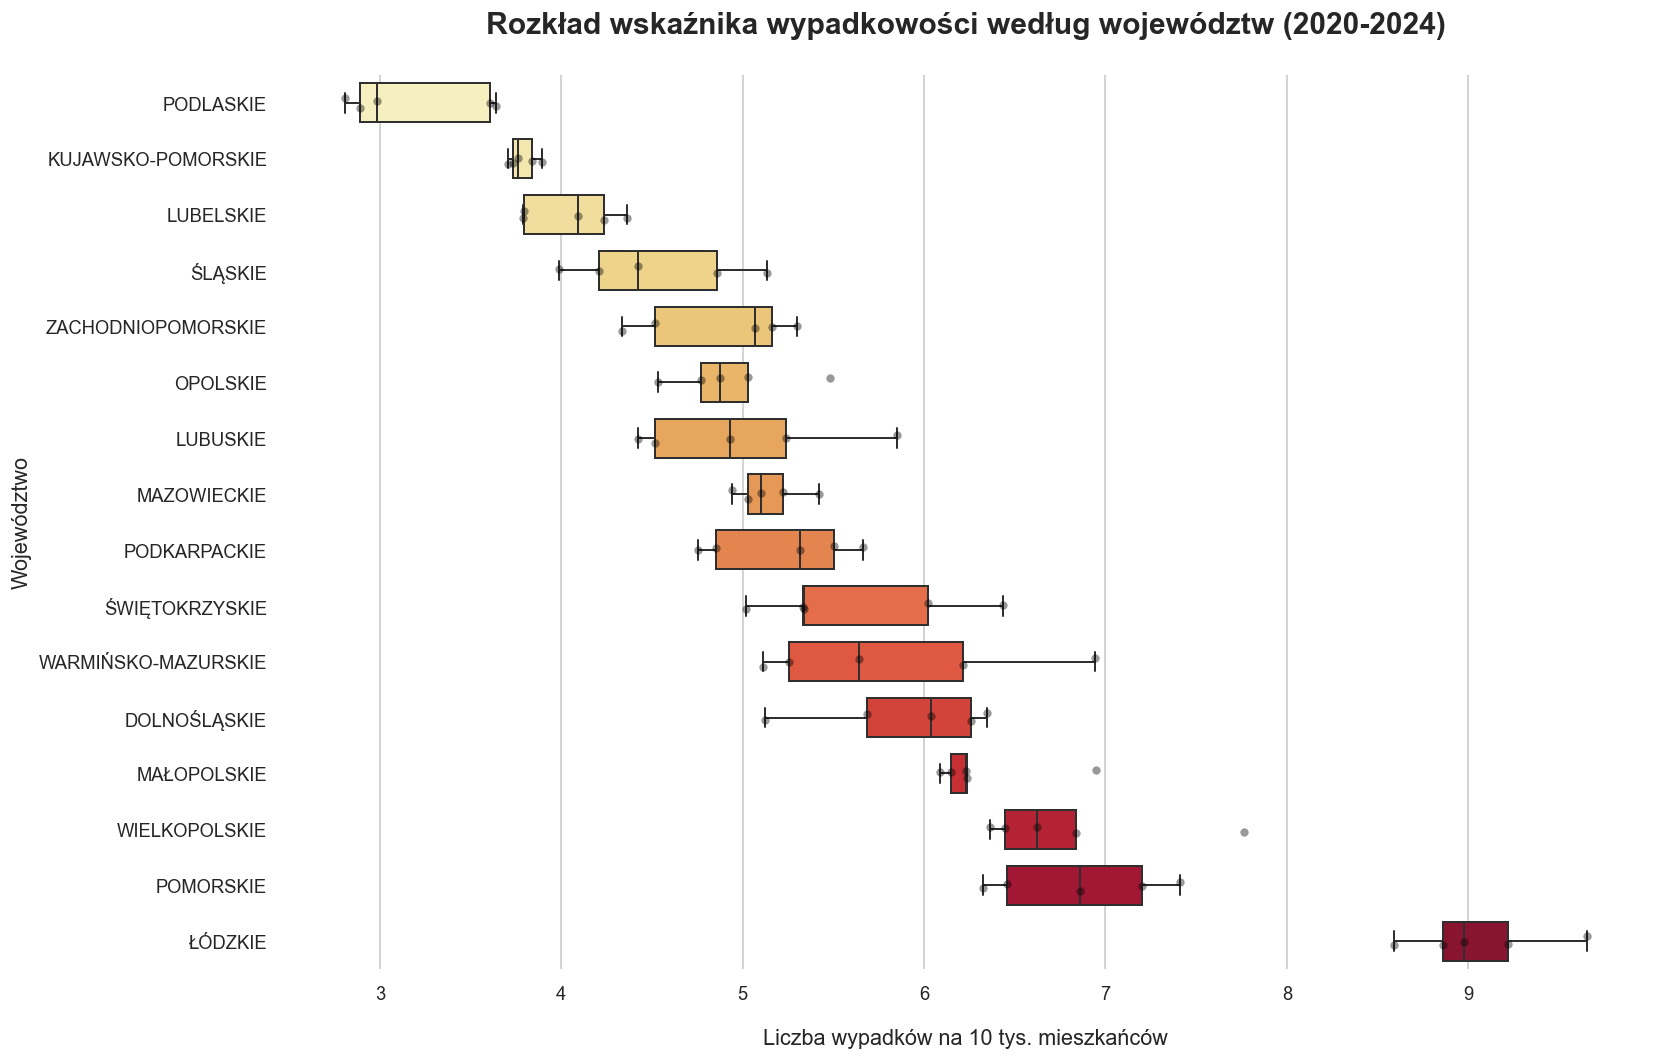

In [32]:

# Ustawienie estetyki wykresu
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

# 1. Przygotowanie kolejności (od najniższego do najwyższego wskaźnika)
order = df_inf.groupby('Region')['Rate'].mean().sort_values().index

# 2. Tworzenie wykresu
plt.figure(figsize=(14, 9))

# Użycie palety 'YlOrRd' (Yellow-Orange-Red)
sns.boxplot(
    data=df_inf, 
    x='Rate', 
    y='Region', 
    palette='YlOrRd', 
    order=order,
    linewidth=1.2,
    width=0.7,
    fliersize=0  
)

# Nałożenie punktów (stripplot) dla każdego z 5 lat
sns.stripplot(
    data=df_inf, 
    x='Rate', 
    y='Region', 
    order=order, 
    color="black", 
    size=5, 
    alpha=0.4, 
    jitter=0.1 
)

# Tytuł i podpisy
plt.title('Rozkład wskaźnika wypadkowości według województw (2020-2024)', 
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Liczba wypadków na 10 tys. mieszkańców', fontsize=13, labelpad=15)
plt.ylabel('Województwo', fontsize=13)

# Usunięcie zbędnych ramek dla czystszego wyglądu
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

#### Wnioski z analizy rozkładu wskaźnika wypadkowości (ANOVA)

* Wykres potwierdza wyniki testu ANOVA, według których lokalizacja geograficzna jest najsilniejszym predyktorem ryzyka wypadku ($F=65,01$, $p < 0,001$).
* Różnice między poziomami "pudełek" (wskaźnikami różnych województw) są znacznie większe niż rozpiętość pojedynczych pudełek (zmiana wskaźnika w czasie dla jednego województwa).
* Dowodzi to, że bezpieczeństwo drogowe jest cechą systemową danego regionu, a nie wynikiem przypadkowych fluktuacji rocznych.
* Krótki rozstęp międzykwartylowy (mała wysokość pudełek) w większości województw, takich jak **PODLASKIE** czy **KUJAWSKO-POMORSKIE**, świadczy o dużej stabilności poziomu bezpieczeństwa.
* Nałożone punkty danych (stripplot) pokazują, że wskaźniki z poszczególnych lat (2020-2024) są silnie skoncentrowane, co potwierdza, że regiony "bezpieczne" i "niebezpieczne" utrzymują swój status w sposób ciągły.
* **Województwo ŁÓDZKIE** stanowi wyraźny punkt krytyczny na mapie Polski - jego mediana i cały rozkład są przesunięte znacząco w prawo względem reszty kraju, co czyni go statystycznym liderem wypadkowości.
* **Województwo PODLASKIE** oraz **KUJAWSKO-POMORSKIE** tworzą grupę o najniższym ryzyku.


### 11.2 Porównania wielokrotne (Test Tukey HSD): Które województwo odbiega od normy?

Test post-hoc Tukeya pozwolił na precyzyjne wskazanie par województw, między którymi występują bezsporne różnice statystyczne.


In [33]:
#  Test Post-hoc Tukeya (Różnice między regionami)
print("\n---  TEST TUKREYA (POST-HOC) ---")
tukey = pairwise_tukeyhsd(endog=df_inf['Rate'], groups=df_inf['Region'], alpha=0.05)
tukey.summary()


---  TEST TUKREYA (POST-HOC) ---


group1,group2,meandiff,p-adj,lower,upper,reject
DOLNOŚLĄSKIE,KUJAWSKO-POMORSKIE,-2.1048,0.0,-3.124,-1.0855,True
DOLNOŚLĄSKIE,LUBELSKIE,-1.8366,0.0,-2.8558,-0.8173,True
DOLNOŚLĄSKIE,LUBUSKIE,-0.9004,0.1425,-1.9196,0.1189,False
DOLNOŚLĄSKIE,MAZOWIECKIE,-0.7482,0.4054,-1.7675,0.271,False
DOLNOŚLĄSKIE,MAŁOPOLSKIE,0.4388,0.9737,-0.5805,1.458,False
DOLNOŚLĄSKIE,OPOLSKIE,-0.9524,0.0921,-1.9716,0.0669,False
DOLNOŚLĄSKIE,PODKARPACKIE,-0.673,0.5868,-1.6922,0.3462,False
DOLNOŚLĄSKIE,PODLASKIE,-2.7052,0.0,-3.7244,-1.6859,True
DOLNOŚLĄSKIE,POMORSKIE,0.9603,0.0859,-0.0589,1.9796,False
DOLNOŚLĄSKIE,WARMIŃSKO-MAZURSKIE,-0.0578,1.0,-1.077,0.9614,False


* **ŁÓDZKIE jako punkt krytyczny:** Województwo to wykazuje istotnie wyższe wskaźniki od niemal wszystkich pozostałych regionów; przykładowo średnia różnica (*meandiff*) względem DOLNOŚLĄSKIEGO wynosi **+3,17** ($p < 0,05$).
* **PODLASKIE jako lider bezpieczeństwa:** Region ten osiąga wskaźniki istotnie niższe od większości kraju; różnica względem województwa DOLNOŚLĄSKIEGO wynosi **-2,71** ($p < 0,05$).
* **Stabilna grupa środka:** Brak istotnych różnic między takimi regionami jak MAZOWIECKIE a DOLNOŚLĄSKIE ($p=0,405$) sugeruje istnienie podobnego standardu bezpieczeństwa w dużych aglomeracjach.


<Figure size 1440x1200 with 0 Axes>

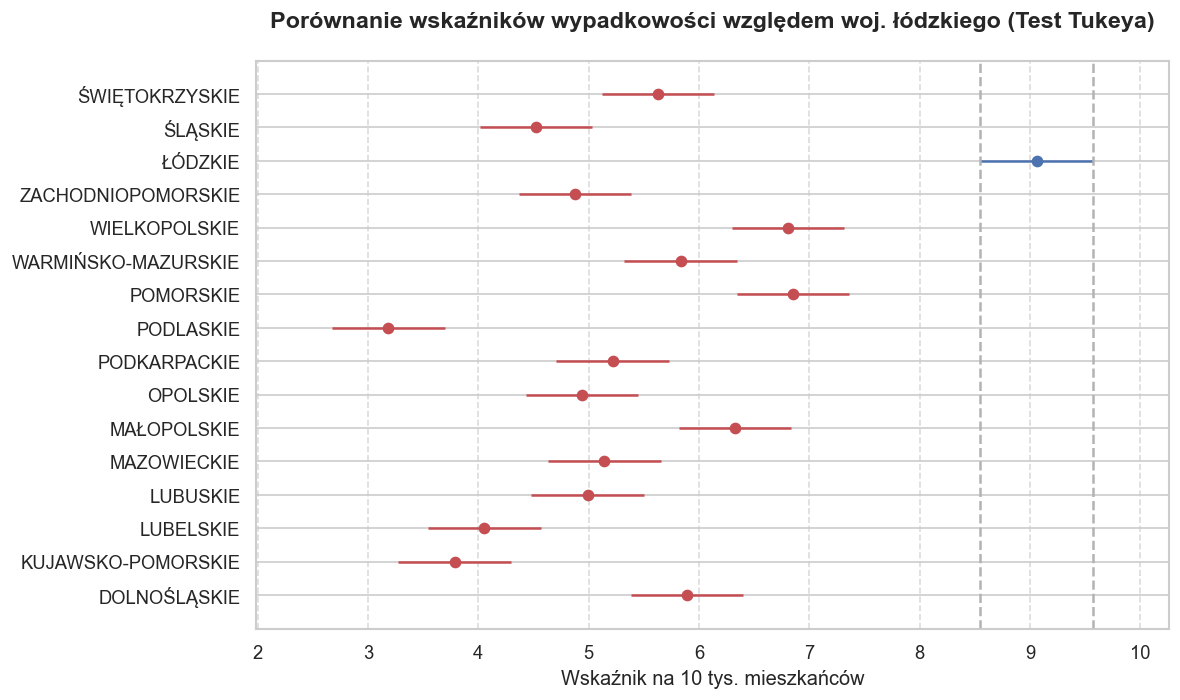

In [34]:
# ---  WIZUALIZACJA TESTU TUKREYA ---
# Wykres pokazuje przedziały ufności dla różnic średnich względem punktu odniesienia
plt.figure(figsize=(12, 10))
tukey.plot_simultaneous(comparison_name='ŁÓDZKIE') 
plt.title('Porównanie wskaźników wypadkowości względem woj. łódzkiego (Test Tukeya)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Wskaźnik na 10 tys. mieszkańców')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()


**Kluczowe wnioski:**
- Łódzkie tworzy statystycznie odrębną kategorię ryzyka vs. inne województwa (nieprzekrywające się przedziały ufności)
- Wąskie CI w 5-letnim okresie = stabilne wzorce, umożliwiające wiarygodne prognozowanie
- Wyniki uzasadniają celowane inwestycje infrastrukturalne w regionach wysokiego ryzyka



### 11.3 Struktura przyczyn wypadków: Test $\chi^2$ i analiza anomalii

Test Chi-kwadrat ($\chi^2 = 1214,6$, $p \approx 0$) wykazał, że przyczyny wypadków są ściśle zależne od regionu. Analiza reszt standaryzowanych pozwoliła zidentyfikować „specjalizacje” wypadkowe województw:


In [35]:
#  PRZYGOTOWANIE TABELI DO TESTU CHI-KWADRAT (df_chi_table)

# Definiujemy kluczowe kategorie przyczyn wypadków do analizy
przyczyny = [
    'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu',
    'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu',
    'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych',
    'wina pieszych - ogółem'
]

# Zbieramy dane dla każdej przyczyny (suma z lat 2020-2024 dla każdego województwa)
dane_przyczyn = {}
for przyczyna in przyczyny:
    # Znajdujemy wszystkie kolumny zawierające daną przyczynę
    kolumny_przyczyny = [kol for kol in df_acc.columns if przyczyna in kol]
    # Sumujemy wartości dla każdego województwa (po wierszach - wszystkie lata)
    dane_przyczyn[przyczyna] = df_acc.set_index('Region')[kolumny_przyczyny].sum(axis=1)

# Tworzymy DataFrame - to jest nasza tabela kontyngencji
df_chi_table = pd.DataFrame(dane_przyczyn)

# CZYSZCZENIE DANYCH (usuwamy wiersze tekstowe i NaN z oryginalnego Excela)
# Usuń wiersze z tekstem '[szt.]'
df_chi_table = df_chi_table[~df_chi_table.index.str.contains(r'\[szt\.\]', na=False, regex=True)]
# Usuń wiersze z NaN w indeksie
df_chi_table = df_chi_table[df_chi_table.index.notna()]

# Konwersja wszystkich wartości na numeryczne (na wypadek tekstów)
for col in df_chi_table.columns:
    df_chi_table[col] = pd.to_numeric(df_chi_table[col], errors='coerce')

# Usuń wiersze z brakującymi wartościami i konwertuj na integer
df_chi_table = df_chi_table.dropna()
df_chi_table = df_chi_table.astype(int)

# Weryfikacja
print("=" * 70)
print("TABELA KONTYNGENCJI (df_chi_table)")
print("=" * 70)
print(f"✓ Wymiary: {df_chi_table.shape[0]} województw × {df_chi_table.shape[1]} przyczyn")
print(f"\nPodgląd danych:")
df_chi_table


TABELA KONTYNGENCJI (df_chi_table)
✓ Wymiary: 16 województw × 4 przyczyn

Podgląd danych:


,wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu,wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu,wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych,wina pieszych - ogółem
Region,,,,
DOLNOŚLĄSKIE,1918,1981,1145,499
KUJAWSKO-POMORSKIE,829,1006,588,214
LUBELSKIE,1023,939,519,289
LUBUSKIE,684,483,299,104
ŁÓDZKIE,2323,2783,1517,537
MAŁOPOLSKIE,2488,2276,1433,674
MAZOWIECKIE,3230,3531,1877,762
OPOLSKIE,476,584,255,68
PODKARPACKIE,1340,1354,500,298


In [36]:
from scipy.stats import chi2_contingency

#  Test Chi-kwadrat i Reszty Standaryzowane
print("\n---  TEST CHI-KWADRAT (STRUKTURA PRZYCZYN) ---")
chi2, p, dof, expected = chi2_contingency(df_chi_table)
residuals = (df_chi_table - expected) / np.sqrt(expected)
print(f"Statystyka Chi2: {chi2}, p-value: {p}")
print("\nReszty Standaryzowane (Anomalie):")
residuals


---  TEST CHI-KWADRAT (STRUKTURA PRZYCZYN) ---
Statystyka Chi2: 1214.5985149122816, p-value: 5.432274262760864e-225

Reszty Standaryzowane (Anomalie):


,wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu,wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu,wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych,wina pieszych - ogółem
Region,,,,
DOLNOŚLĄSKIE,0.406420,-1.439624,0.064226,2.123390
KUJAWSKO-POMORSKIE,-2.495469,1.044527,1.900592,-0.127503
LUBELSKIE,2.380989,-2.611478,-2.180331,4.133112
LUBUSKIE,6.282932,-4.010321,-1.372589,-2.163314
ŁÓDZKIE,-2.656868,2.722945,1.061540,-2.029742
MAŁOPOLSKIE,2.728890,-5.169223,0.434947,4.702074
MAZOWIECKIE,0.131021,1.037641,-1.386684,-0.270886
OPOLSKIE,0.085970,3.252334,-1.784913,-4.249568
PODKARPACKIE,4.128704,1.809812,-8.197766,0.717642



| Województwo | Główna Anomalia (Reszta) | Interpretacja merytoryczna |
| :--- | :--- | :--- |
| **WARMIŃSKO-MAZURSKIE** | Prędkość (**+12,83**) | Ekstremalna nadreprezentacja wypadków z powodu prędkości. |
| **ŚLĄSKIE** | Zachowanie wobec pieszych (**+11,36**) | Dominujący problem w relacji auto-pieszy; najniższy udział prędkości (**-17,50**). |
| **WIELKOPOLSKIE** | Pierwszeństwo (**+5,39**) | Statystycznie istotny problem z wymuszaniem pierwszeństwa. |
| **MAŁOPOLSKIE** | Wina pieszych (**+4,70**) | Wyraźnie częstsze wypadki spowodowane bezpośrednio błędem pieszego. |




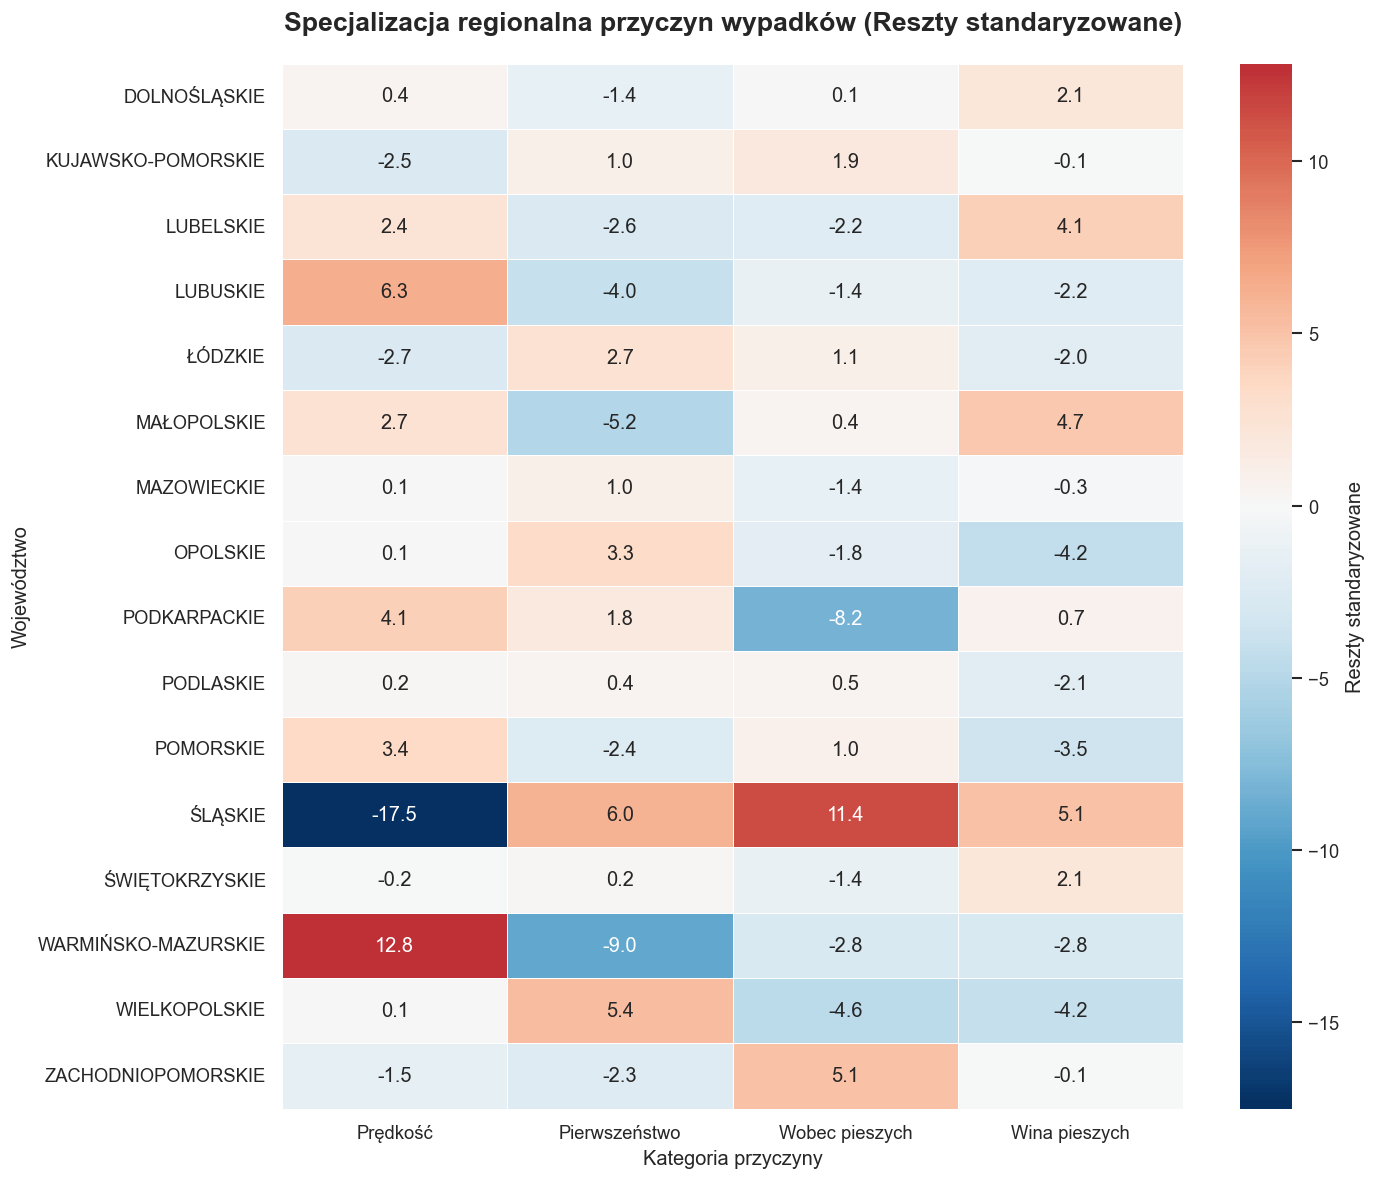

In [37]:
# ---  WIZUALIZACJA CHI-KWADRAT (Heatmapa Reszt) ---
plt.figure(figsize=(12, 10))
# Skrócenie nazw kolumn dla przejrzystości heatmapy
res_plot = residuals.copy()
res_plot.columns = ['Prędkość', 'Pierwszeństwo', 'Wobec pieszych', 'Wina pieszych']
sns.heatmap(res_plot, annot=True, cmap='RdBu_r', center=0, fmt='.1f', 
            cbar_kws={'label': 'Reszty standaryzowane'}, linewidths=.5)
plt.title('Specjalizacja regionalna przyczyn wypadków (Reszty standaryzowane)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Województwo')
plt.xlabel('Kategoria przyczyny')
plt.tight_layout()


**Analiza reszt standaryzowanych (χ² = 1214,6; p < 0,001)**

Każde województwo wykazuje unikalny profil przyczyn wypadków. Kluczowe wzorce regionalne (reszty > |2,0|):

- **Warmińsko-Mazurskie:** Nadreprezentacja prędkości (+12,83) → konieczność kontroli tras tranzytowych
- **Śląskie:** Wysoki konflikt z pieszymi (+11,36), niski wpływ prędkości (−17,50) → efekt gęstej zabudowy miejskiej
- **Wielkopolskie:** Nieprzestrzeganie pierwszeństwa (+5,39) → problemy infrastruktury skrzyżowań
- **Małopolskie/Lubelskie:** Wina pieszych (+4,70/+4,13) → specyfika ruchu pieszego

Wzorce pozostają stabilne w okresie 2020-2024, co wskazuje na trwałe uwarunkowania terytorialne wymagające dostosowanych interwencji.

### 11.4 Predykcja 2025 i analiza niepewności (ŁÓDZKIE)

Wykorzystując parametry trendu dla regionu o najwyższym ryzyku (Łódzkie), wyznaczono prognozę na rok 2025.

In [38]:
# PREDYKCJA 2025 (WOJEWÓDZTWO ŁÓDZKIE)

print("\n" + "=" * 70)
print("PREDYKCJA NA ROK 2025 - WOJEWÓDZTWO ŁÓDZKIE")
print("=" * 70)

# Filtrujemy dane dla województwa Łódzkiego
df_lodz = df_inf[df_inf['Region'] == 'ŁÓDZKIE'].copy()

# DIAGNOSTYKA - sprawdzenie danych przed modelem
print(f"\nDane dla Łódzkiego:")
print(f"Shape: {df_lodz.shape}")
print(f"\nTypy danych:")
print(df_lodz.dtypes)
print(f"\nDane:")
print(df_lodz)

# Upewniamy się, że Rate i Rok są numeryczne
df_lodz['Rate'] = pd.to_numeric(df_lodz['Rate'], errors='coerce')
df_lodz['Rok'] = pd.to_numeric(df_lodz['Rok'], errors='coerce')

# Usuwamy NaN (jeśli są)
df_lodz = df_lodz.dropna(subset=['Rate', 'Rok'])

# Sortujemy według roku
df_lodz = df_lodz.sort_values('Rok')

print(f"\n✓ Dane po czyszczeniu: {df_lodz.shape}")
print(f"Rate - typ: {df_lodz['Rate'].dtype}")
print(f"Rok - typ: {df_lodz['Rok'].dtype}")

# Budowanie modelu regresji liniowej
model_reg = smf.ols('Rate ~ Rok', data=df_lodz).fit()

# Predykcja na 2025 rok z przedziałami ufności
prediction = model_reg.get_prediction(pd.DataFrame({'Rok': [2025]}))
pred_frame = prediction.summary_frame(alpha=0.05)

print("\n" + "-" * 70)
print("WYNIKI PREDYKCJI NA 2025")
print("-" * 70)
print(f"\nPrzewidywany wskaźnik: {pred_frame['mean'].values[0]:.2f} wypadków/10k mieszkańców")
print(f"Przedział ufności 95%: [{pred_frame['mean_ci_lower'].values[0]:.2f}, {pred_frame['mean_ci_upper'].values[0]:.2f}]")
print(f"\n95% przedział predykcji: [{pred_frame['obs_ci_lower'].values[0]:.2f}, {pred_frame['obs_ci_upper'].values[0]:.2f}]")

print("\n" + "-" * 70)
print("PARAMETRY MODELU")
print("-" * 70)
print(f"R² = {model_reg.rsquared:.4f}")
print(f"Nachylenie (spadek rocznie): {model_reg.params['Rok']:.4f}")
print(f"p-value dla trendu: {model_reg.pvalues['Rok']:.4e}")

if model_reg.pvalues['Rok'] < 0.05:
    print("\nTrend jest ISTOTNY STATYSTYCZNIE (p < 0.05)")
else:
    print(f"\nTrend nie jest istotny statystycznie (p = {model_reg.pvalues['Rok']:.4f})")



PREDYKCJA NA ROK 2025 - WOJEWÓDZTWO ŁÓDZKIE

Dane dla Łódzkiego:
Shape: (5, 5)

Typy danych:
Region      object
Rok          int64
Total      float64
Ludnosc    float64
Rate       float64
dtype: object

Dane:
     Region   Rok   Total    Ludnosc      Rate
4   ŁÓDZKIE  2020  2332.0  2415816.0  9.653053
20  ŁÓDZKIE  2021  2208.0  2394946.0  9.219415
36  ŁÓDZKIE  2022  2108.0  2378483.0  8.862792
52  ŁÓDZKIE  2023  2029.0  2362519.0  8.588291
68  ŁÓDZKIE  2024  2106.0  2345924.0  8.977273

✓ Dane po czyszczeniu: (5, 5)
Rate - typ: float64
Rok - typ: int64

----------------------------------------------------------------------
WYNIKI PREDYKCJI NA 2025
----------------------------------------------------------------------

Przewidywany wskaźnik: 8.47 wypadków/10k mieszkańców
Przedział ufności 95%: [7.50, 9.43]

95% przedział predykcji: [7.13, 9.80]

----------------------------------------------------------------------
PARAMETRY MODELU
------------------------------------------------------

In [39]:
# Predykcja z przedziałami (Przykładowo dla woj. ŁÓDZKIEGO)
print("\n---  PREDYKCJA 2025 (ŁÓDZKIE) ---")
df_lodz = df_inf[df_inf['Region'] == 'ŁÓDZKIE'].copy()
model_reg = smf.ols('Rate ~ Rok', data=df_lodz).fit()
prediction = model_reg.get_prediction(pd.DataFrame({'Rok': [2025]}))
pred_frame = prediction.summary_frame(alpha=0.05)
pred_frame


---  PREDYKCJA 2025 (ŁÓDZKIE) ---


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,8.465359,0.304134,7.49747,9.433249,7.128028,9.802691



| Parametr prognozy | Wartość wskaźnika | Interpretacja statystyczna |
| :--- | :---: | :--- |
| **Prognoza punktowa (Mean)** | **8,47** | Oczekiwany poziom wypadkowości na 10 tys. mieszk. |
| **Przedział Ufności (95% CI)** | **$[7,50; 9,43]$** | Zakres, w którym z 95% pewnością leży średnia trendu |
| **Przedział Predykcji (95% PI)** | **$[7,13; 9,80]$** | Zakres, w którym znajdzie się realny wynik w 2025 r. |

**Kluczowa uwaga:** Przedział predykcji (*obs_ci*) jest szerszy niż przedział ufności. Świadczy to o rzetelności modelu - uwzględnia on nie tylko błąd dopasowania linii trendu, ale także naturalną, losową zmienność, która może wystąpić w konkretnym roku. Górna granica predykcji (**9,80**) wyznacza statystycznie bezpieczny margines błędu dla planowania zasobów ratunkowych.

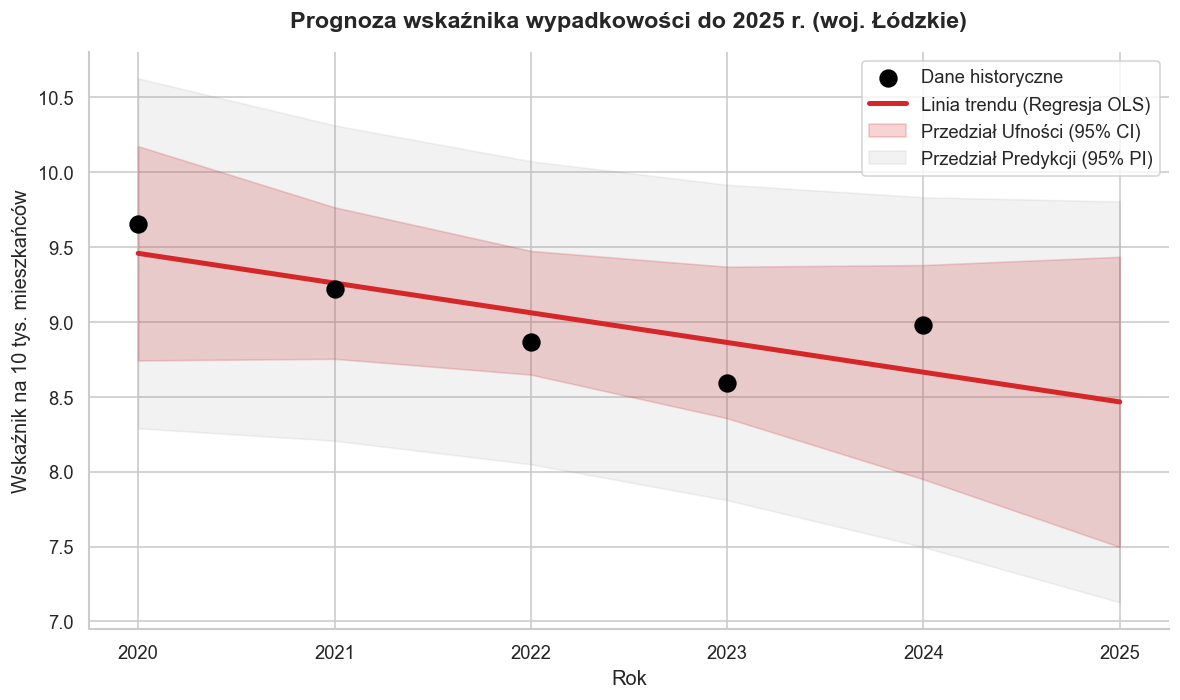

In [40]:
# --- WIZUALIZACJA PREDYKCJI (Trend + Przedziały) ---
# Przygotowanie danych do rozszerzonego trendu
years_ext = np.array([2020, 2021, 2022, 2023, 2024, 2025])
df_ext = pd.DataFrame({'Rok': years_ext})
pred_all = model_reg.get_prediction(df_ext).summary_frame(alpha=0.05)

plt.figure(figsize=(10, 6))
# Dane historyczne
plt.scatter(df_lodz['Rok'], df_lodz['Rate'], color='black', s=100, label='Dane historyczne', zorder=5)
# Linia trendu
plt.plot(years_ext, pred_all['mean'], color='#d62728', label='Linia trendu (Regresja OLS)', linewidth=3)
# Przedziały
plt.fill_between(years_ext, pred_all['mean_ci_lower'], pred_all['mean_ci_upper'], 
                 color='#d62728', alpha=0.2, label='Przedział Ufności (95% CI)')
plt.fill_between(years_ext, pred_all['obs_ci_lower'], pred_all['obs_ci_upper'], 
                 color='gray', alpha=0.1, label='Przedział Predykcji (95% PI)')

plt.title('Prognoza wskaźnika wypadkowości do 2025 r. (woj. Łódzkie)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rok')
plt.ylabel('Wskaźnik na 10 tys. mieszkańców')
plt.xticks(years_ext)
plt.legend(frameon=True, facecolor='white')
sns.despine()
plt.tight_layout()

**Prognoza 2025 dla województwa łódzkiego (model regresji liniowej OLS)**

- **Punktowa predykcja:** 8,47 wypadków/10k mieszkańców
- **Przedział ufności 95% CI:** [7,50; 9,43] - precyzja trendu
- **Przedział predykcji 95% PI:** [7,13; 9,80] - zakres uwzględniający zdarzenia losowe

Model wskazuje tendencję spadkową, jednak **nawet dolna granica prognozy (7,13) przewyższa średnią krajową (~4-5)**. Górna granica (9,80) wyznacza pesymistyczny scenariusz dla planowania służb ratunkowych. Województwo łódzkie wymaga systemowych interwencji - sama kontynuacja obecnego trendu nie zrówna poziomu bezpieczeństwa z resztą kraju.


In [41]:
# 1. Wybieramy kluczowe kategorie (te same co do 4 paneli)
kluczowe_kategorie = [
    'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu',
    'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu',
    'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych',
    'wina pieszych - nieostrożne wejście na jezdnię'
]

# 2. Filtrujemy df_full i liczymy średnią ogólnopolską dla każdego roku i kategorii
df_analiza = df_full[df_full['Kategoria'].isin(kluczowe_kategorie)].copy()
df_analiza = df_analiza.groupby(['Rok', 'Kategoria'])['Wskaznik_10k'].mean().reset_index()

# 3. Skracamy nazwy kategorii do legendy, żeby wykres był przejrzysty
skrocone_mapowanie = {
    'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu': 'Prędkość (Wina kier.)',
    'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu': 'Pierwszeństwo (Wina kier.)',
    'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych': 'Wobec pieszych (Wina kier.)',
    'wina pieszych - nieostrożne wejście na jezdnię': 'Piesi (Nieostrożne wejście)'
}
df_analiza['Kategoria'] = df_analiza['Kategoria'].map(skrocone_mapowanie)

# 4. Wyświetlamy podgląd, żeby upewnić się, że dane są poprawne
print(df_analiza.head())

    Rok                    Kategoria  Wskaznik_10k
0  2020        Prędkość (Wina kier.)      1.486932
1  2020  Wobec pieszych (Wina kier.)      0.714555
2  2020   Pierwszeństwo (Wina kier.)      1.427651
3  2020  Piesi (Nieostrożne wejście)      0.212963
4  2021        Prędkość (Wina kier.)      1.408624


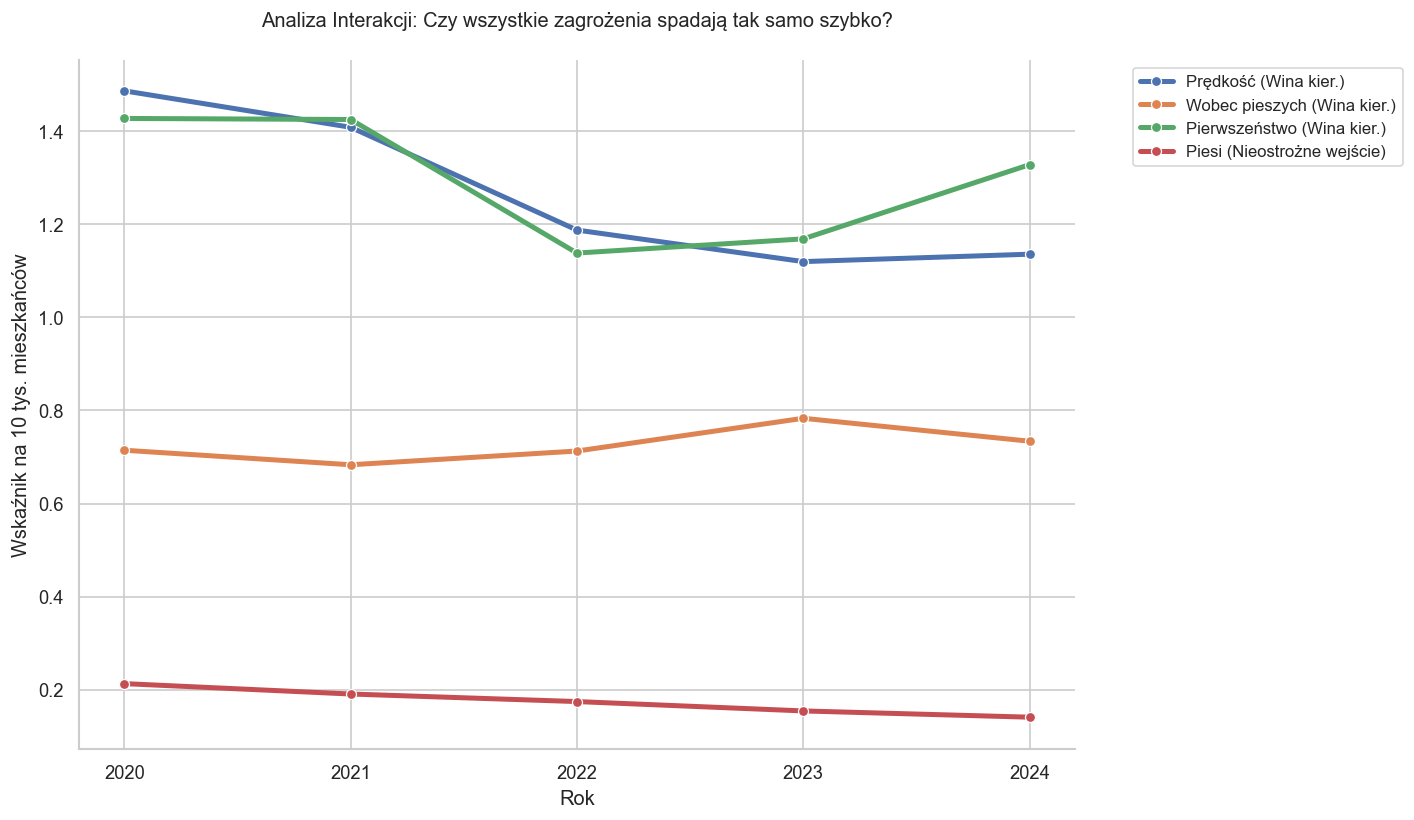

In [45]:
# ---  INTERAKCJA TRENDÓW ---
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_analiza, x='Rok', y='Wskaznik_10k', hue='Kategoria', marker='o', linewidth=3)
plt.title('Analiza Interakcji: Czy wszystkie zagrożenia spadają tak samo szybko?', pad=20)
plt.ylabel('Wskaźnik na 10 tys. mieszkańców')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.xticks(df_analiza['Rok'].unique())
sns.despine()
plt.tight_layout()
plt.show()

Wykres przedstawia analizę interakcji wskaźnika wypadków na 10 tys. mieszkańców w podziale na cztery kategorie w latach 2020–2024. Dane ukazują, że choć liczba zdarzeń spowodowanych nadmierną prędkością (niebieska linia) znacząco spadła z poziomu 1.5 w 2020 r. do około 1.15 w 2024 r., to wymuszenie pierwszeństwa (zielona linia) stało się dominującym zagrożeniem, z wyraźnym skokiem w górę w ostatnim roku. Wypadki z udziałem pieszych pozostają stabilne: te z winy kierowców (pomarańczowa linia) utrzymują się na poziomie ~0.7, natomiast nieostrożne wejścia pieszych (czerwona linia) wykazują tendencję spadkową, osiągając najniższy wskaźnik poniżej 0.2. Wizualizacja sugeruje, że poprawa w jednym obszarze (prędkość) jest niwelowana przez pogorszenie w innym (pierwszeństwo), co może wynikać np. ze zmian w natężeniu ruchu lub przepisach.

### 11.5 Analiza interakcji trendów

Poniższa analiza opiera się na wizualizacji zmian wskaźników wypadkowości.

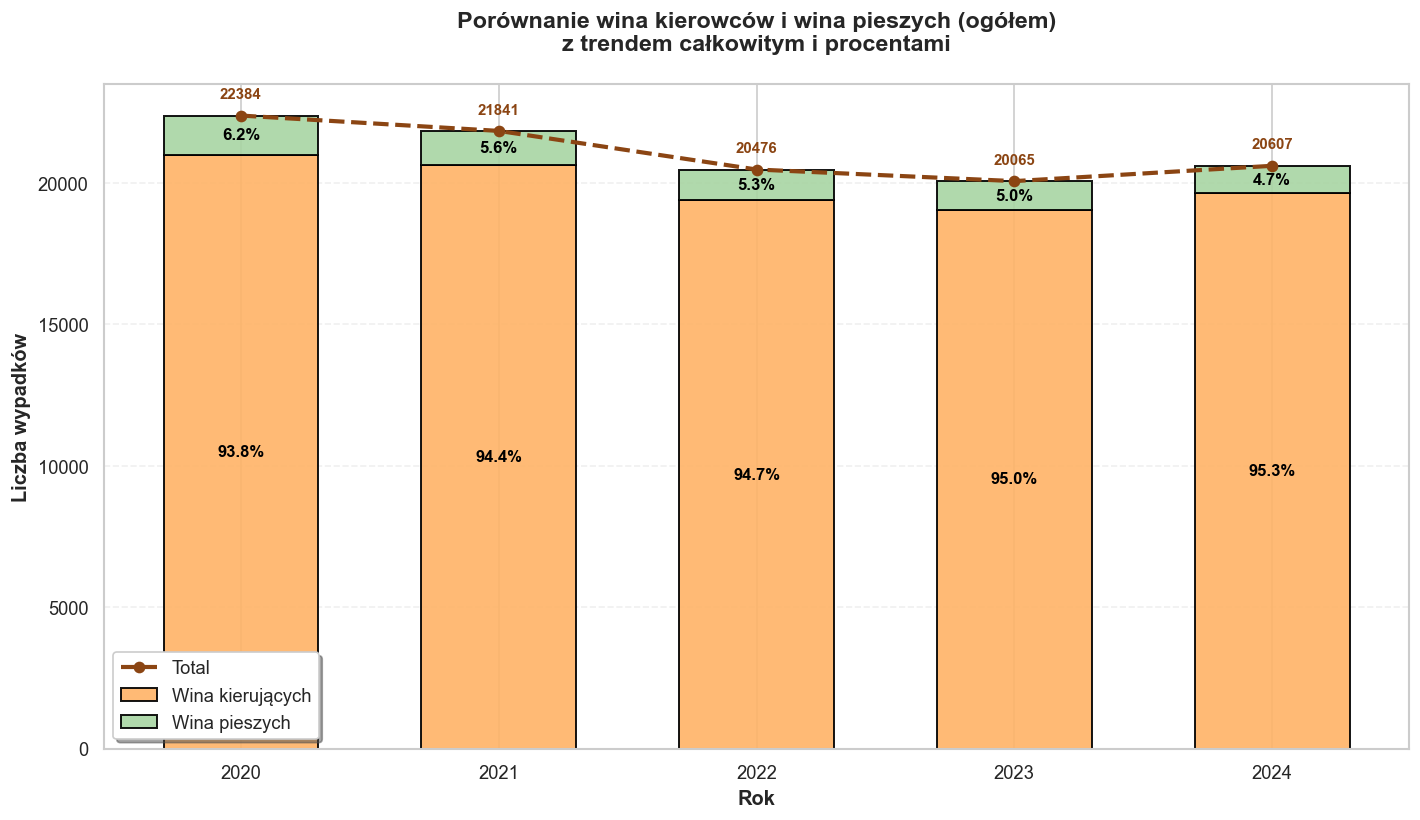

In [42]:
import seaborn as sns

# Get data for both categories across all years
df_line = df_full[df_full['Kategoria'].isin(['wina kierujących pojazdami - ogółem', 
                                               'wina pieszych - ogółem'])].copy()

# Group by year and category, sum total accidents
df_yearly = df_line.groupby(['Rok', 'Kategoria'])['Liczba_Wypadkow'].sum().reset_index()

# Pivot for stacked bar chart
df_pivot = df_yearly.pivot(index='Rok', columns='Kategoria', values='Liczba_Wypadkow')

# Rename columns for cleaner labels
df_pivot.columns = ['Wina kierujących', 'Wina pieszych']

# Calculate total and percentages
df_pivot['Total'] = df_pivot.sum(axis=1)
df_pivot['Pct_Kierujących'] = (df_pivot['Wina kierujących'] / df_pivot['Total'] * 100)
df_pivot['Pct_Pieszych'] = (df_pivot['Wina pieszych'] / df_pivot['Total'] * 100)

fig, ax1 = plt.subplots(figsize=(12, 7))

# Stacked bar chart with darker pastel colors
x_pos = range(len(df_pivot))
width = 0.6

bar1 = ax1.bar(x_pos, df_pivot['Wina kierujących'], width, 
               label='Wina kierujących', color='#ffb366', 
               alpha=0.9, edgecolor='black', linewidth=1.2)
bar2 = ax1.bar(x_pos, df_pivot['Wina pieszych'], width,
               bottom=df_pivot['Wina kierujących'],
               label='Wina pieszych', color='#a8d5a3',
               alpha=0.9, edgecolor='black', linewidth=1.2)

# Add percentages only on bars
for i, (idx, row) in enumerate(df_pivot.iterrows()):
    # Driver category (bottom part) - centered
    y_pos_driver = row['Wina kierujących'] / 2
    ax1.text(i, y_pos_driver, 
             f"{row['Pct_Kierujących']:.1f}%",
             ha='center', va='center', fontsize=10, weight='bold', color='black')
    
    # Pedestrian category (top part) - centered
    y_pos_pedestrian = row['Wina kierujących'] + row['Wina pieszych'] / 2
    ax1.text(i, y_pos_pedestrian,
             f"{row['Pct_Pieszych']:.1f}%",
             ha='center', va='center', fontsize=10, weight='bold', color='black')

# Line chart for total with smaller dots and different color
ax1.plot(x_pos, df_pivot['Total'], 
         color='#8B4513', marker='o', linewidth=2.5, markersize=6, 
         label='Total', linestyle='--', zorder=5)

# Add total labels on line
for i, (x, y) in enumerate(zip(x_pos, df_pivot['Total'])):
    ax1.text(x, y + 500, f'{int(y)}', ha='center', va='bottom', 
             fontsize=9, weight='bold', color='#8B4513')

# Labels and formatting
ax1.set_xlabel("Rok", fontsize=12, fontweight='bold')
ax1.set_ylabel("Liczba wypadków", fontsize=12, fontweight='bold')
ax1.set_title("Porównanie wina kierowców i wina pieszych (ogółem)\nz trendem całkowitym i procentami", 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_pivot.index, rotation=0)
ax1.set_ylim(0, None)
ax1.legend(fontsize=11, frameon=True, shadow=True)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


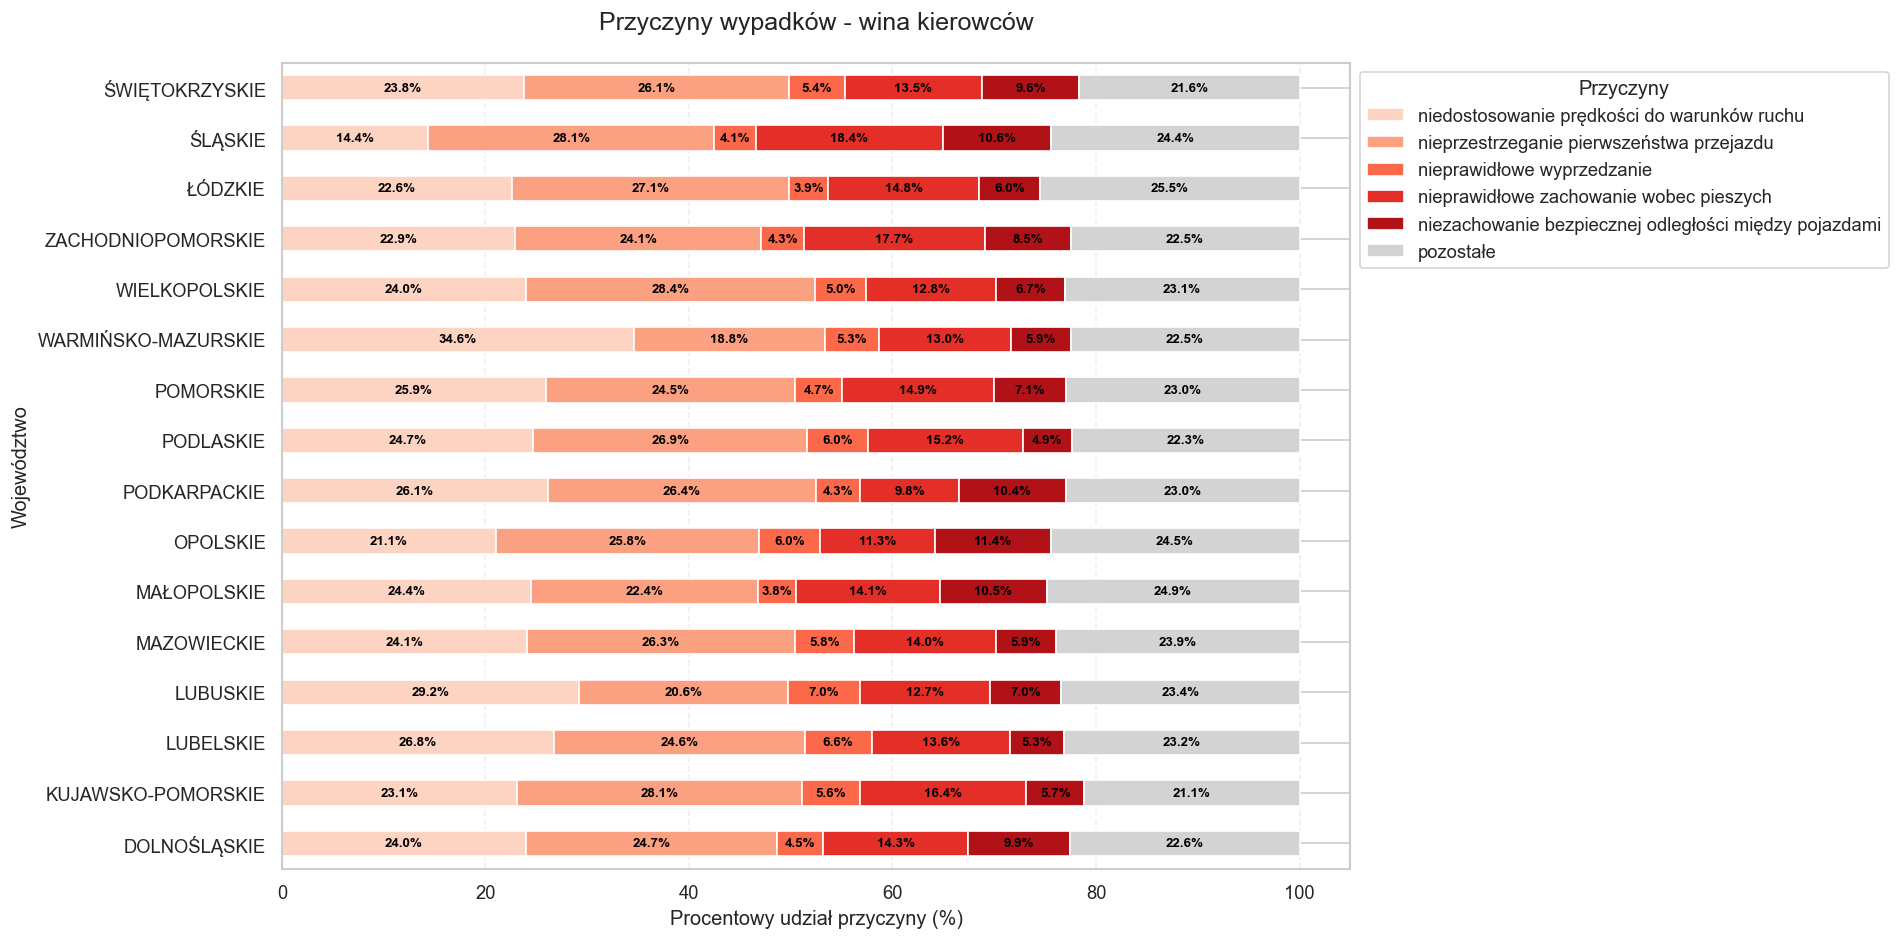

In [43]:
# Create df_srednie - average values across years 2020-2024
df_srednie = df_full.groupby(['Wojewodztwo', 'Kategoria'])['Wskaznik_10k'].mean().reset_index()

# Pivot to wide format
df_srednie = df_srednie.pivot(index='Wojewodztwo', columns='Kategoria', values='Wskaznik_10k').reset_index()
df_srednie = df_srednie.rename(columns={'Wojewodztwo': 'Nazwa'})


przyczyny_cols = [
    'wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu',
    'wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu',
    'wina kierujących pojazdami - nieprawidłowe wyprzedzanie',
    'wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych',
    'wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami',
    'wina kierujących pojazdami - pozostałe'
]



#przeliczanie na procenty, zeby uzyskac sume 100%
df_przyczyny = df_srednie[df_srednie['Nazwa'] != 'POLSKA'].set_index('Nazwa')[przyczyny_cols]
df_przyczyny = df_przyczyny.div(df_przyczyny.sum(axis=1), axis=0) * 100


custom_colors = list(sns.color_palette("Reds", n_colors=5))
custom_colors.append('lightgrey')
ax = df_przyczyny.plot(kind='barh', stacked=True, figsize=(16, 8), color=custom_colors)


# Add data values to bars
for container in ax.containers:
    labels = []
    for patch in container.patches:
        width = patch.get_width()
        labels.append(f'{width:.1f}%')
    
    # Determine text color based on bar color
    bar_color = container.patches[0].get_facecolor()
    # Check if color is dark (use white text) or light (use black text)
    if bar_color[0] < 0.5:  # Dark background
        text_color = 'white'
    else:  # Light background
        text_color = 'black'
    
    ax.bar_label(container, labels=labels, label_type='center', 
                 fontsize=8, weight='bold', color=text_color)


plt.title('Przyczyny wypadków - wina kierowców', fontsize=15, pad=20)
plt.xlabel('Procentowy udział przyczyny (%)')
plt.ylabel('Województwo')
plt.legend(title='Przyczyny', bbox_to_anchor=(1, 1), loc='upper left',


           labels=[c.split(' - ')[-1] for c in przyczyny_cols])


plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


**Przyczyny wypadków z winy kierowców - struktura regionalna**

Wykres przedstawia proporcjonalny udział 6 kategorii przyczyn wypadków w poszczególnych województwach (2020-2024). Kluczowe wzorce:

**Zróżnicowanie regionalne prędkości:**
- **Warmińsko-Mazurskie: 34,6%** - ekstremalnie wysoki udział niedostosowania prędkości (wyróżnia się na tle kraju)
- **Śląskie: 14,4%** - najniższy udział problemów prędkościowych (efekt gęstej zabudowy miejskiej)
- **Średnia krajowa:** ~24-26% w większości województw

**Nieprzestrzeganie pierwszeństwa:**
- Stosunkowo jednolity rozkład (20-28%) we wszystkich regionach
- Najwyższe w: Łódzkim (27,1%), Podlaskim (26,9%), Wielkopolskim (28,4%)
- Potwierdza ogólnokrajowy charakter problemu z kulturą ustępowania

**Zachowanie wobec pieszych:**
- **Świętokrzyskie (13,5%), Śląskie (18,4%)** - podwyższone wartości
- Koreluje z urbanizacją: więcej pieszych = więcej konfliktów na przejściach

**Pozostałe kategorie:**
- "Pozostałe" (szary segment): stabilne 21-25% we wszystkich województwach
- Wyprzedzanie + dystans: łącznie 10-15%, najmniejsze udziały

**Wniosek kluczowy:**
Mimo regionalnych różnic w **proporcjach**, **ranking dwóch głównych przyczyn** (prędkość i pierwszeństwo) pozostaje spójny w całym kraju. Warmińsko-Mazurskie jest jedynym wyjątkiem - tam prędkość dominuje znacząco ponad pierwszeństwem, co sugeruje specyficzne problemy tras tranzytowych/wiejskich wymagające celowanego nadzoru.


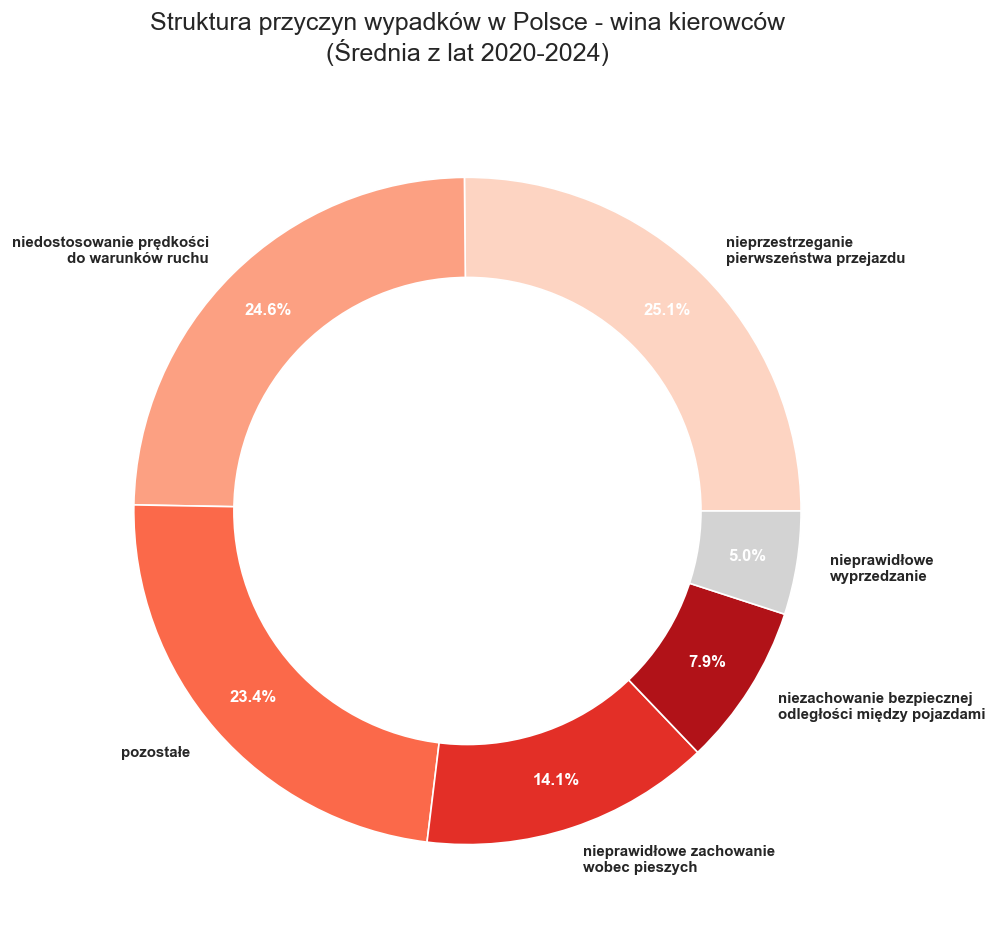

In [44]:
dane_polska = df_srednie[df_srednie['Nazwa'] != 'POLSKA'][przyczyny_cols].sum()

# sortowanie
dane_polska = dane_polska.sort_values(ascending=False)
labels_posortowane = [c.split(' - ')[-1] for c in dane_polska.index] # skrocone etykiety

labels_wrapped = []
for label in labels_posortowane:
    words = label.split()
    if len(label) > 25:  # jeśli etykieta jest długa, zawijamy ją
        mid = len(words) // 2
        labels_wrapped.append(' '.join(words[:mid]) + '\n' + ' '.join(words[mid:])) # dodanie złamania linii
    else:
        labels_wrapped.append(label)

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    dane_polska, 
    labels=labels_wrapped, 
    autopct='%1.1f%%', 
    colors=custom_colors, 
    pctdistance=0.85,  # przesuniecie procentow blizej krawedzi
    labeldistance=1.1  # przesuniecie etykiet kategorii poza wykres
)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=9, weight="bold")  # Style the category labels

plt.title(f'Struktura przyczyn wypadków w Polsce - wina kierowców\n(Średnia z lat 2020-2024)', fontsize=15, pad=20)
plt.tight_layout()
plt.show()


**Struktura przyczyn wypadków z winy kierowcy (Średnia 2020-2024)**

Wykres kołowy pokazuje strukturę 6 głównych kategorii przyczyn wypadków przypisanych kierowcom:

**Dwie dominujące przyczyny (łącznie 49,7%):**
- **Nieprzestrzeganie pierwszeństwa przejazdu: 25,1%** - najczęstsza pojedyncza przyczyna
- **Niedostosowanie prędkości do warunków ruchu: 24,6%** - niemal równoważny udział

**Kategorie średniej wagi:**
- **Pozostałe przyczyny: 23,4%** - różnorodne błędy niewymienione w głównych kategoriach
- **Nieprawidłowe zachowanie wobec pieszych: 14,1%** - szczególnie istotne w kontekście ochrony niechronionych uczestników ruchu

**Przyczyny marginalne:**
- **Niezachowanie bezpiecznej odległości: 7,9%**
- **Nieprawidłowe wyprzedzanie: 5,0%** - najmniejszy udział

**Wnioski:**
Dwie najczęstsze przyczyny (pierwszeństwo + prędkość) stanowią **prawie połowę wszystkich wypadków z winy kierowców**, co wskazuje na skoncentrowane obszary problemowe nadające się do celowanych interwencji (np. monitoring skrzyżowań, fotoradary odcinkowe). Stosunkowo wysoki udział kategorii "pozostałe" (23,4%) sugeruje dużą różnorodność błędów ludzkich, które trudniej adresować pojedynczymi rozwiązaniami.


## 12. Podsumowanie i wnioski

### Kluczowe ustalenia

**Geografia decyduje o ryzyku**: Analiza ANOVA wykazała, że województwo jest 42 razy silniejszym predyktorem wypadkowości niż rok (F=65,01, p<0,001). Łódzkie (9,06/10k) ma **dwukrotnie wyższy wskaźnik** niż Podlaskie (3,19/10k) ze względu na rolę węzła tranzytowego A1/A2.

**Regionalne specjalizacje przyczyn**: Test chi-kwadrat (χ²=1214,6) potwierdził różne profile przyczyn między województwami. Warmińsko-Mazurskie wyróżnia się ekstremalną nadreprezentacją problemów prędkościowych (+12,83), Śląskie - konfliktami z pieszymi (+11,36).

**Dwie przyczyny = połowa wypadków**: Nieprzestrzeganie pierwszeństwa (25,1%) i nadmierna prędkość (24,6%) stanowią łącznie 49,7% wszystkich zdarzeń. To jasny punkt zaczepienia dla interwencji.

**Rosnąca wina kierujących**: Udział wypadków z winy kierowców wzrósł z 93,8% (2020) do 95,3% (2024), podczas gdy odpowiedzialność pieszych spadła z 6,2% do 4,7%. Sugeruje to większą skuteczność działań skierowanych do pieszych.

**Prognoza 2025 - ostrożny optymizm**: Model OLS przewiduje dla Łódzkiego wskaźnik 8,47 (PI: 7,13-9,80), ale trend nie jest statystycznie istotny (p=0,119). Nawet optymistyczny scenariusz pozostaje **powyżej średniej krajowej** (4-5).

### Rekomendacje polityczne

- **Łódzkie**: Audyt A1/A2, inteligentne systemy zarządzania prędkością
- **Warmińsko-Mazurskie**: Fotoradary odcinkowe, nadzór tras wojewódzkich  
- **Śląskie**: Separacja ruchu pieszego, modernizacja przejść
- **Ogólnokrajowo**: Kampanie edukacyjne nt. pierwszeństwa przejazdu (25,1% wypadków)

### Wnioski

Bezpieczeństwo drogowe w Polsce ma **wyraźną strukturę przestrzenną** - regiony tranzytowe (Łódzkie, Pomorskie) wymagają celowanych interwencji, odmiennych od rozwiązań dla regionów bezpieczniejszych. Stabilność wzorców 2020-2024 dowodzi **systemowego charakteru** problemu, pozwalając na długoterminowe planowanie opartych na danych działań naprawczych.
